# Analiza Ról Użytkowników w Debatach Dezinformacyjnych
## Projekt: Kto napędza dyskusję?

**Cel:** Profilowanie ról użytkowników i pomiar "temperatury" dyskusji w subredditach

---

### Metodologia:
1. **Data Engineering** - Rekonstrukcja sieci interakcji
2. **Feature Engineering** - Wyliczenie cech użytkowników
3. **Temperature Index** - Metryka intensywności sporu
4. **Clustering** - Identyfikacja ról (K-Means)
5. **Wizualizacja** - Graf sieciowy z kolorami klastrów

## 📚 ETAP 1: Import Bibliotek i Wczytanie Danych

Instalujemy i importujemy wszystkie potrzebne biblioteki do analizy sieciowej, NLP i ML.

In [1]:
# Instalacja wymaganych pakietów (uruchom jednokrotnie)
import sys
%pip install -q pandas numpy networkx scikit-learn matplotlib seaborn nltk textblob tqdm pyvis

# Pobieranie leksykonów VADER dla analizy sentymentu
import nltk
nltk.download('vader_lexicon', quiet=True)
print("✓ Wszystkie pakiety zainstalowane (w tym tqdm i pyvis)")

Note: you may need to restart the kernel to use updated packages.
✓ Wszystkie pakiety zainstalowane (w tym tqdm i pyvis)


In [2]:
# Import standardowych bibliotek
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# NLP - Analiza sentymentu
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Ustawienia wizualizacji
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("✓ Biblioteki zaimportowane")

✓ Biblioteki zaimportowane


In [3]:
# Wczytanie danych z CSV
# UWAGA: Zmień ścieżkę na właściwą dla Twojego pliku
flatearth_data_path = './flatearth.csv'
aliens_data_path = './aliens.csv'
chemitrails_data_path = './chemtrails.csv'
news_data_path = './news.csv'

flatearth_df = pd.read_csv(flatearth_data_path)
aliens_df = pd.read_csv(aliens_data_path)
chemitrails_df = pd.read_csv(chemitrails_data_path)
news_df = pd.read_csv(news_data_path)

dataframes = {
    'flatearth': flatearth_df,
    'aliens': aliens_df,
    'chemtrails': chemitrails_df,
    'news': news_df
}

# Konwersja timestamp na datetime
for df in dataframes.values():
    df['timestamp'] = pd.to_datetime(df['timestamp'])

# Pierwsze spojrzenie na dane
for name, df in dataframes.items():
    print(f'\n\n{name}')
    print(f"📊 Załadowano {len(df)} wierszy")
    print(f"📅 Zakres czasowy: {df['timestamp'].min()} → {df['timestamp'].max()}")
    print(f"👥 Liczba unikalnych autorów: {df['author'].nunique()}")
    print(f"💬 Typy aktywności: {df['activity_type'].value_counts().to_dict()}")

    # Podgląd struktury
    df.head()



flatearth
📊 Załadowano 17606 wierszy
📅 Zakres czasowy: 2015-09-25 15:42:23+00:00 → 2026-01-13 06:18:55+00:00
👥 Liczba unikalnych autorów: 4668
💬 Typy aktywności: {'comment': 17170, 'post': 436}


aliens
📊 Załadowano 34030 wierszy
📅 Zakres czasowy: 2014-01-26 21:00:24+00:00 → 2026-01-08 16:03:03+00:00
👥 Liczba unikalnych autorów: 14045
💬 Typy aktywności: {'comment': 33649, 'post': 381}


chemtrails
📊 Załadowano 39657 wierszy
📅 Zakres czasowy: 2013-02-21 16:37:52+00:00 → 2026-01-20 19:21:35+00:00
👥 Liczba unikalnych autorów: 8415
💬 Typy aktywności: {'comment': 39222, 'post': 435}


news
📊 Załadowano 68703 wierszy
📅 Zakres czasowy: 2009-06-25 21:47:51+00:00 → 2026-01-21 07:19:31+00:00
👥 Liczba unikalnych autorów: 30255
💬 Typy aktywności: {'comment': 68241, 'post': 462}


### Add post_id to each row

In [4]:
for name, df in dataframes.items():
    df["post_id"] = np.where(
        df["activity_type"] == "post",
        df["activity_id"],
        np.nan
    )

    id_to_post_id = dict(zip(df["activity_id"], df["post_id"]))
    changed = True

    while changed:
        changed = False

        for idx, row in df[df["post_id"].isna()].iterrows():
            parent = row["parent_id"]

            if parent in id_to_post_id and pd.notna(id_to_post_id[parent]):
                df.at[idx, "post_id"] = id_to_post_id[parent]
                id_to_post_id[row["activity_id"]] = id_to_post_id[parent]
                changed = True


### Get comment threads

In [5]:
comments_df_dict = {
    name: df[df["activity_type"] == "comment"].copy()
    for name, df in dataframes.items()
}

#### parent comment timestamp

In [6]:
for name, df in dataframes.items():
    comments_df = comments_df_dict[name]
    parent_lookup = dict(zip(df["activity_id"], df["parent_id"]))
    timestamp_lookup = dict(zip(df["activity_id"], df["timestamp"]))
    type_lookup = dict(zip(df["activity_id"], df["activity_type"]))

    def get_direct_parent_timestamp(comment_id):
        parent = parent_lookup.get(comment_id)
        return timestamp_lookup.get(parent)

    comments_df["parent_timestamp"] = comments_df["activity_id"].apply(
        get_direct_parent_timestamp
    )


#### number of replies

In [7]:
for name, df in dataframes.items():
    comments_df = comments_df_dict[name]
    comments = comments_df.copy()

    reply_counts = (
        comments
        .groupby('parent_id')
        .size()
        .rename('num_replies')
    )

    comments = comments.merge(
        reply_counts,
        left_on='activity_id',
        right_index=True,
        how='left'
    )

    comments['num_replies'] = comments['num_replies'].fillna(0)
    comments_df_dict[name] = comments

#### reply delay

In [8]:
for name, df in dataframes.items():
    comments = comments_df_dict[name]

    comments['timestamp'] = pd.to_datetime(comments['timestamp'])
    comments['parent_timestamp'] = pd.to_datetime(
        comments['parent_timestamp']
    )

    comments['reply_delay_sec'] = (
        comments['timestamp'] - comments['parent_timestamp']
    ).dt.total_seconds()


#### response speed

In [9]:
for name, df in dataframes.items():
    comments = comments_df_dict[name]

    median_reply_time = (
        comments
        .groupby('parent_id')['reply_delay_sec']
        .median()
        .rename('median_reply_seconds')
    )

    comments = comments.merge(
        median_reply_time,
        left_on='activity_id',
        right_index=True,
        how='left'
    )

    comments['response_speed'] = (
        1 / (comments['median_reply_seconds'] + 1)
    ).fillna(0)

    comments_df_dict[name] = comments

## Calculate temperature for comments

In [10]:
from sklearn.preprocessing import MinMaxScaler

features = ['replies_log', 'score_log', 'response_speed']

for name, comments in comments_df_dict.items():

    winsorize = ['score', 'response_speed']
    upper = comments[winsorize].quantile(0.999)
    score_lower = comments['score'].quantile(0.001)

    comments[winsorize] = comments[winsorize].clip(upper=upper, axis=1)
    comments['score'] = comments['score'].clip(lower=score_lower)

    comments['replies_log'] = np.log1p(comments['num_replies'])
    comments['score_log'] = np.log1p(comments['score'].abs())

    scaler = MinMaxScaler()
    comments[features] = scaler.fit_transform(comments[features])

    comments['comment_ignition_score'] = (
        0.5 * comments['replies_log'] +
        0.25 * comments['response_speed'] +
        0.25 * comments['score_log']
    )

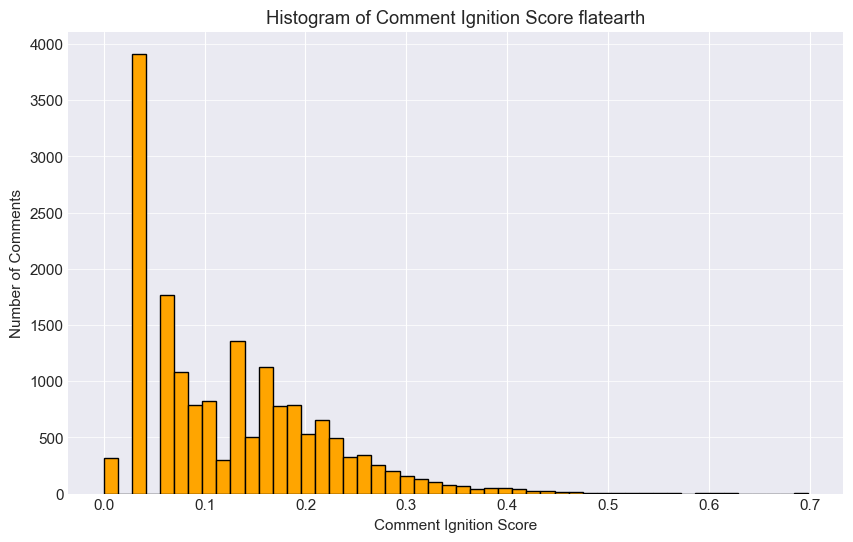

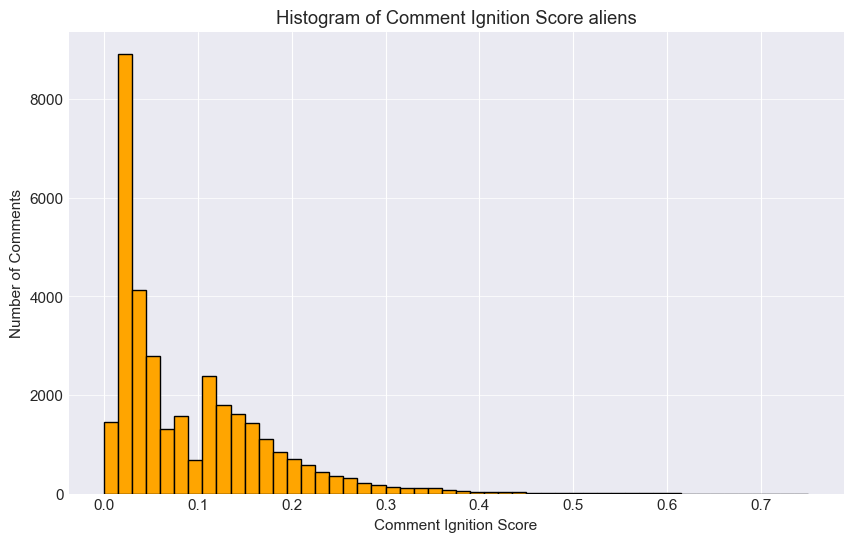

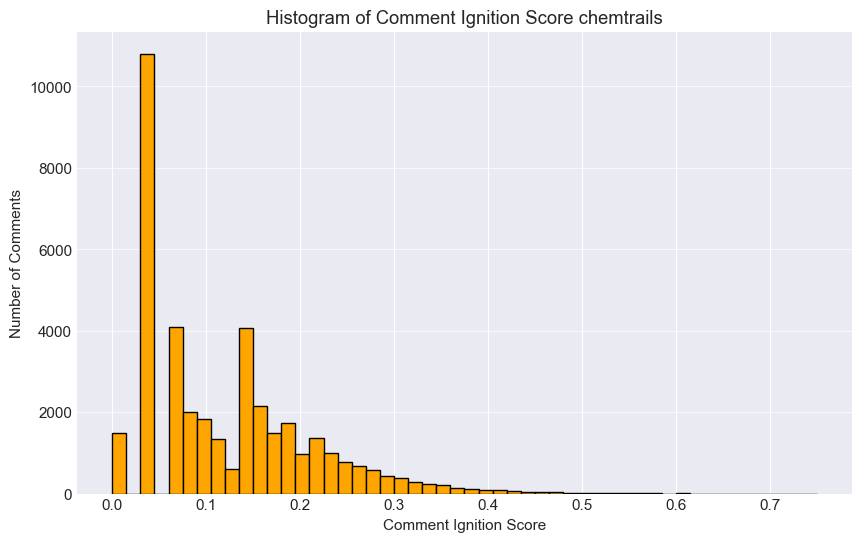

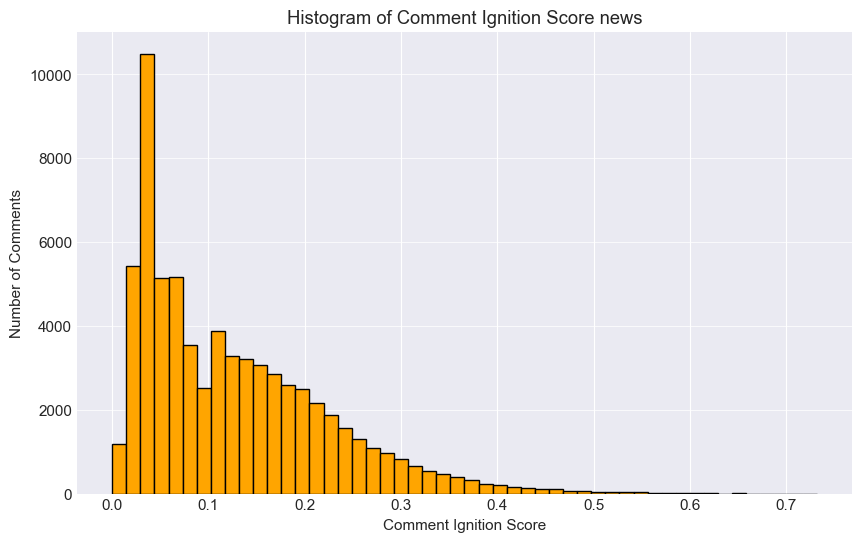

In [11]:
import matplotlib.pyplot as plt

for name, comments in comments_df_dict.items():
    plt.figure(figsize=(10,6))
    plt.hist(comments['comment_ignition_score'], bins=50, color='orange', edgecolor='black')
    plt.title(f'Histogram of Comment Ignition Score {name}')
    plt.xlabel('Comment Ignition Score')
    plt.ylabel('Number of Comments')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

## 🔗 ETAP 2: Data Engineering - Rekonstrukcja Sieci Interakcji

**Problem:** Kolumna `parent_id` wskazuje na activity_id rodzica, ale nie mamy bezpośrednio informacji o autorze, do którego kierowany jest komentarz.

**Rozwiązanie:** Tworzymy mapowanie `activity_id → author`, a następnie dla każdego komentarza znajdujemy `target_author` przez lookup `parent_id`.

In [11]:
# KROK 1: Czyszczenie danych - usunięcie botów i usuniętych użytkowników
print("🧹 Czyszczenie danych...")
cleaned_comments = {}

for name, df in comments_df_dict.items():
    initial_count = len(df)
    df = df[~df['author'].isin(['[deleted]', '[removed]', 'AutoModerator'])].copy()
    df = df[df['author'].notna()].copy()
    cleaned_comments[name] = df

    print(f'\n\n{name}')
    print(f"  Usunięto {initial_count - len(df)} wierszy (boty, usunięci użytkownicy)")
    print(f"  Pozostało: {len(df)} aktywności od {df['author'].nunique()} użytkowników")

🧹 Czyszczenie danych...


flatearth
  Usunięto 2020 wierszy (boty, usunięci użytkownicy)
  Pozostało: 15150 aktywności od 4615 użytkowników


aliens
  Usunięto 5867 wierszy (boty, usunięci użytkownicy)
  Pozostało: 27782 aktywności od 13979 użytkowników


chemtrails
  Usunięto 4792 wierszy (boty, usunięci użytkownicy)
  Pozostało: 34430 aktywności od 8367 użytkowników


news
  Usunięto 18502 wierszy (boty, usunięci użytkownicy)
  Pozostało: 49739 aktywności od 30040 użytkowników


## 🔬 ETAP 3: Feature Engineering - Profilowanie Użytkowników

Dla każdego użytkownika wyliczamy zestaw cech, które posłużą do klasteryzacji:
- **Aktywność:** liczba postów, komentarzy, stosunek post/comment
- **Sieć:** in-degree, out-degree, PageRank
- **Sentyment:** średnia i odchylenie standardowe (VADER)
- **Kontrowersja:** średnie upvote_ratio i score

In [12]:
# Przygotowanie analizatora sentymentu
print("💭 Inicjalizacja analizy sentymentu (VADER)...")
sia = SentimentIntensityAnalyzer()

# Import tqdm dla paska postępu
from tqdm.notebook import tqdm
tqdm.pandas()

def get_sentiment(text):
    """Zwraca wynik sentymentu (compound score od -1 do 1)"""
    if pd.isna(text) or text == '[deleted]':
        return 0.0
    try:
        return sia.polarity_scores(str(text))['compound']
    except:
        return 0.0

for name, df in cleaned_comments.items():
    # Dodanie kolumny sentymentu do DataFrame z paskiem postępu
    print("  Obliczanie sentymentu dla wszystkich wypowiedzi...")
    df['sentiment'] = df['content'].apply(get_sentiment)
    print(f"  ✓ Sentiment score: min={df['sentiment'].min():.2f}, max={df['sentiment'].max():.2f}, mean={df['sentiment'].mean():.2f}")

💭 Inicjalizacja analizy sentymentu (VADER)...
  Obliczanie sentymentu dla wszystkich wypowiedzi...
  ✓ Sentiment score: min=-0.99, max=0.99, mean=0.04
  Obliczanie sentymentu dla wszystkich wypowiedzi...
  ✓ Sentiment score: min=-1.00, max=1.00, mean=0.06
  Obliczanie sentymentu dla wszystkich wypowiedzi...
  ✓ Sentiment score: min=-1.00, max=1.00, mean=0.02
  Obliczanie sentymentu dla wszystkich wypowiedzi...
  ✓ Sentiment score: min=-1.00, max=1.00, mean=-0.06


In [13]:
# Wyliczanie cech dla każdego użytkownika
print("📊 Wyliczanie cech użytkowników...")

users_dict = {}

for name, df in cleaned_comments.items():

    user_features = {}

    for author in df['author'].unique():
        user_comments = df[df['author'] == author]

        num_comments = len(user_comments)
        total_replies = user_comments['num_replies'].sum()
        avg_replies = user_comments['num_replies'].median()
        avg_comment_delay = user_comments['reply_delay_sec'].median()
        avg_response_speed = user_comments['response_speed'].median()
        avg_abs_score = user_comments['score'].abs().median()

        sentiments = user_comments['sentiment'].dropna()
        avg_sentiment = sentiments.median() if len(sentiments) > 0 else 0

        ignition_score_mean = user_comments['comment_ignition_score'].mean()
        ignition_score_median = user_comments['comment_ignition_score'].median()
        ignition_score_top10_mean = user_comments['comment_ignition_score'].nlargest(10).mean()

        user_features[author] = {
            'num_comments': num_comments,
            'total_replies': total_replies,
            'avg_replies': avg_replies,
            'avg_comment_delay': avg_comment_delay,
            'avg_response_speed': avg_response_speed,
            'avg_abs_score': avg_abs_score,
            'avg_sentiment': avg_sentiment,
            'ignition_score_mean': ignition_score_mean,
            'ignition_score_median': ignition_score_median,
            'ignition_score_top10_mean': ignition_score_top10_mean,
        }

    # Konwersja do DataFrame
    user_df = pd.DataFrame.from_dict(user_features, orient='index')
    users_dict[name] = user_df

    print(f'\n\n{name}')
    print(f"  ✓ Wyliczono cechy dla {len(user_df)} użytkowników")
    print(f"\n📈 Przegląd statystyk:")
    print(user_df.describe().T)

📊 Wyliczanie cech użytkowników...


flatearth
  ✓ Wyliczono cechy dla 4615 użytkowników

📈 Przegląd statystyk:
                            count           mean           std     min  \
num_comments               4615.0       3.282774  7.773757e+00  1.0000   
total_replies              4615.0       2.139978  7.361870e+00  0.0000   
avg_replies                4615.0       0.441820  7.451081e-01  0.0000   
avg_comment_delay          4615.0  854753.873239  8.675763e+06  2.5000   
avg_response_speed         4615.0       0.008294  4.534788e-02  0.0000   
avg_abs_score              4615.0       3.664061  6.004663e+00  0.0000   
avg_sentiment              4615.0       0.033242  3.662083e-01 -0.9753   
ignition_score_mean        4615.0       0.109809  7.471094e-02  0.0000   
ignition_score_median      4615.0       0.107887  7.621531e-02  0.0000   
ignition_score_top10_mean  4615.0       0.113201  7.826838e-02  0.0000   

                                   25%           50%           75%  \
num_

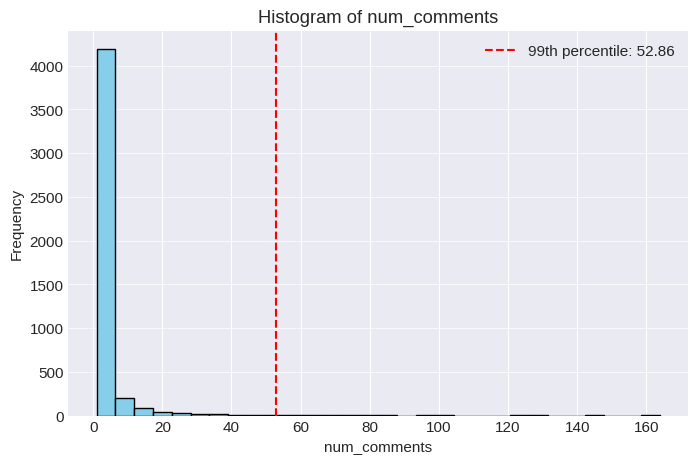

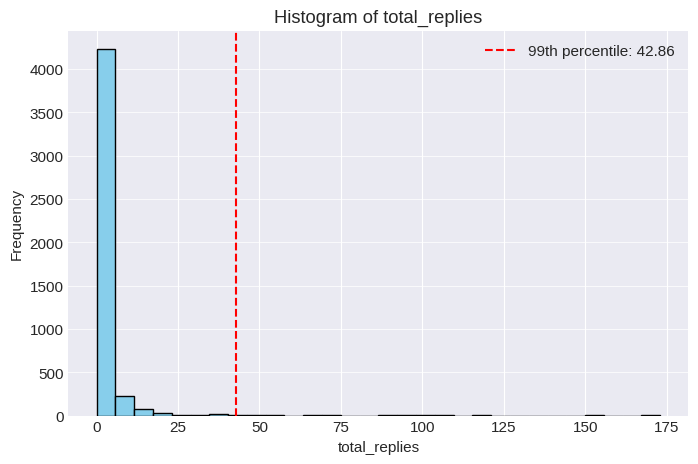

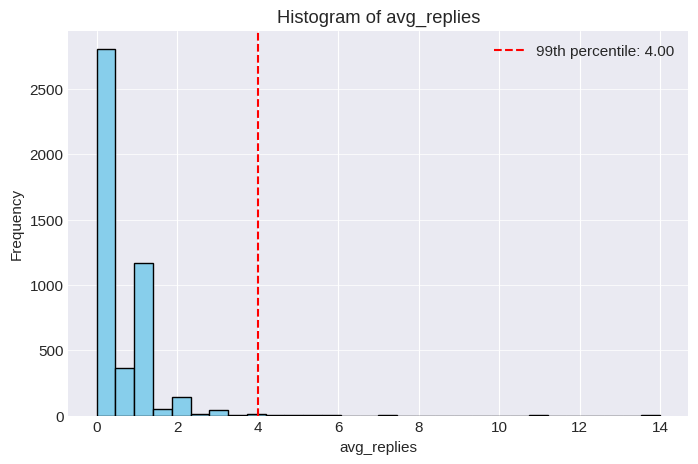

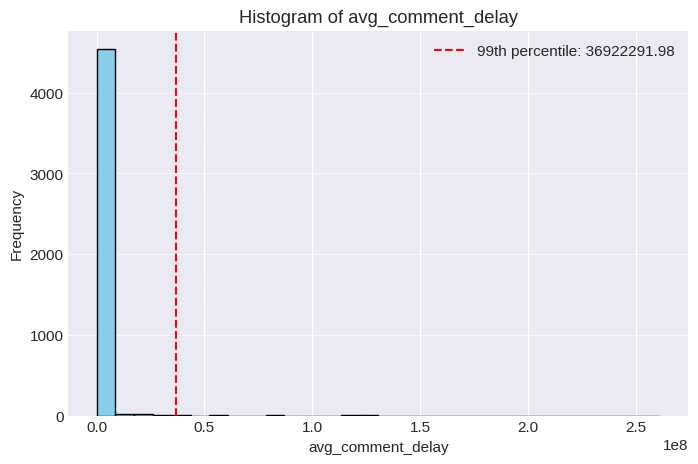

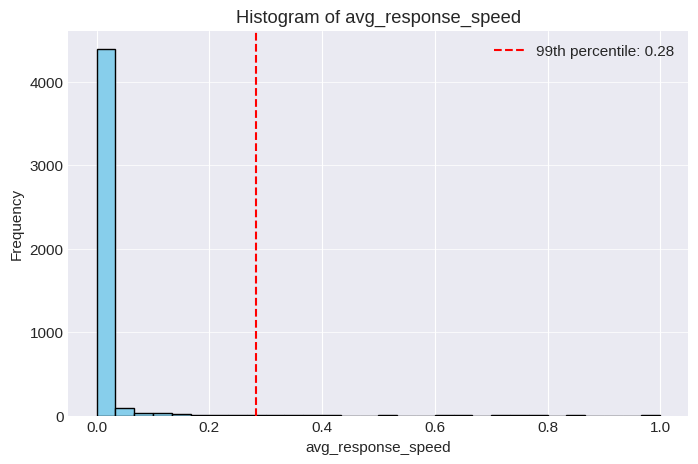

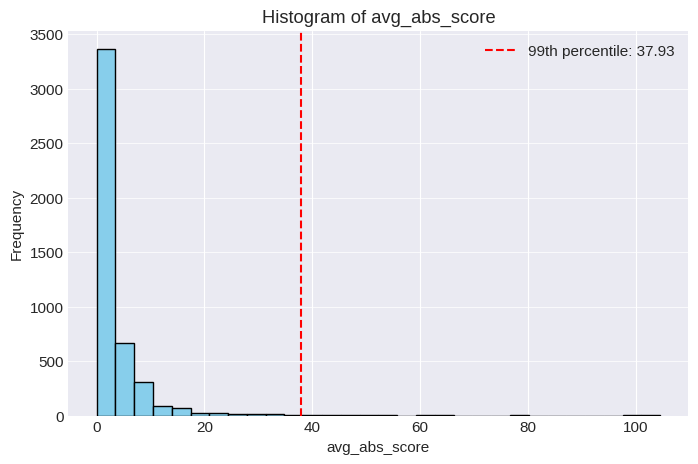

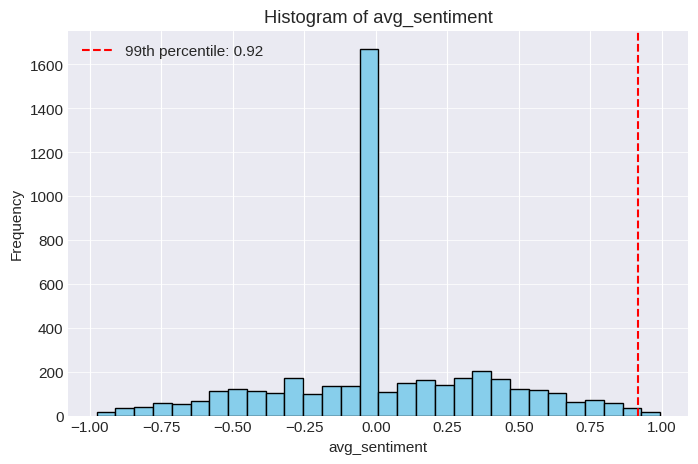

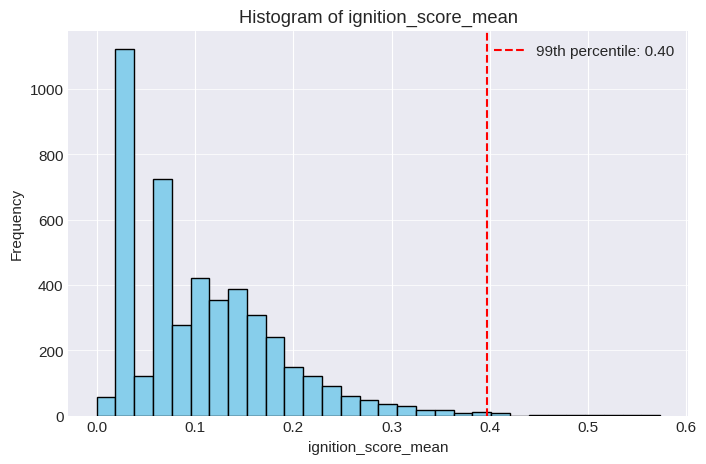

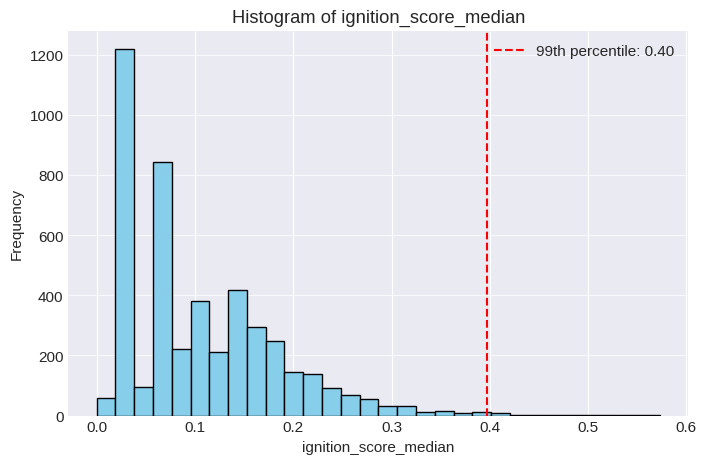

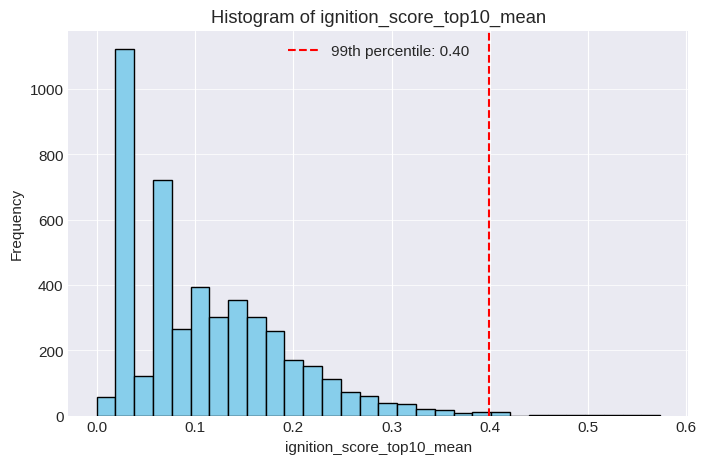

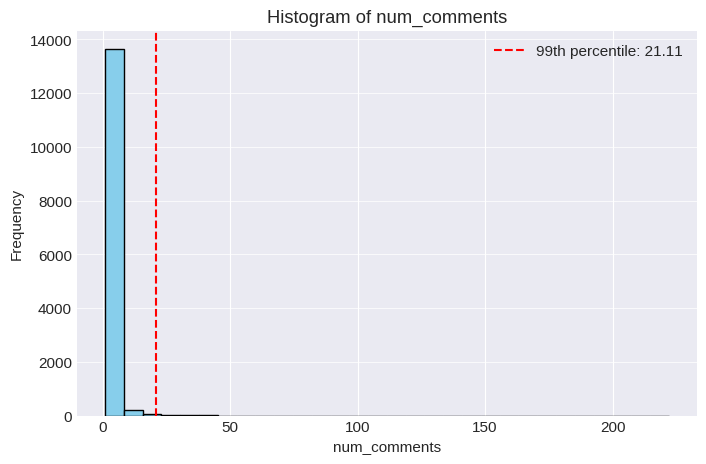

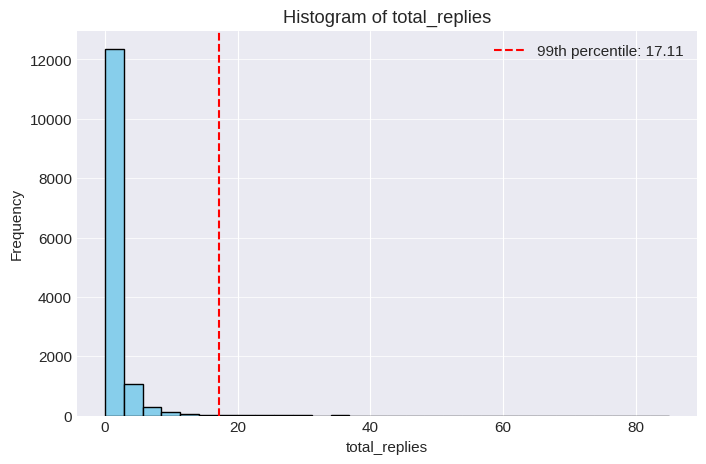

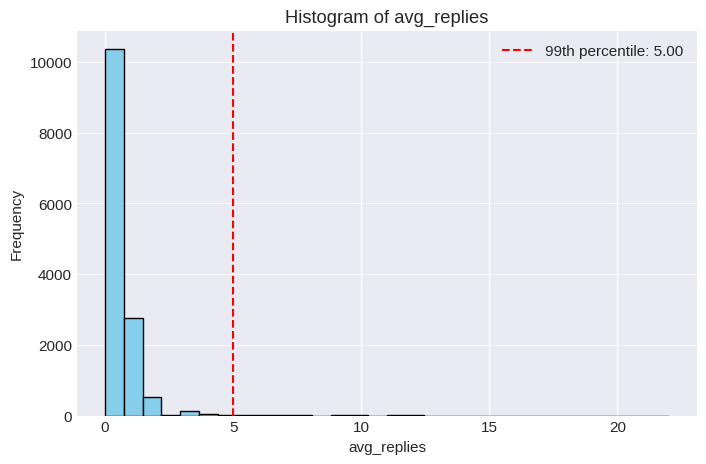

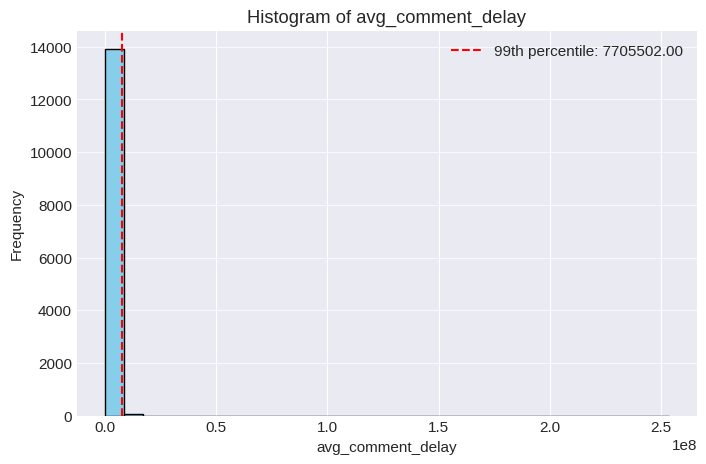

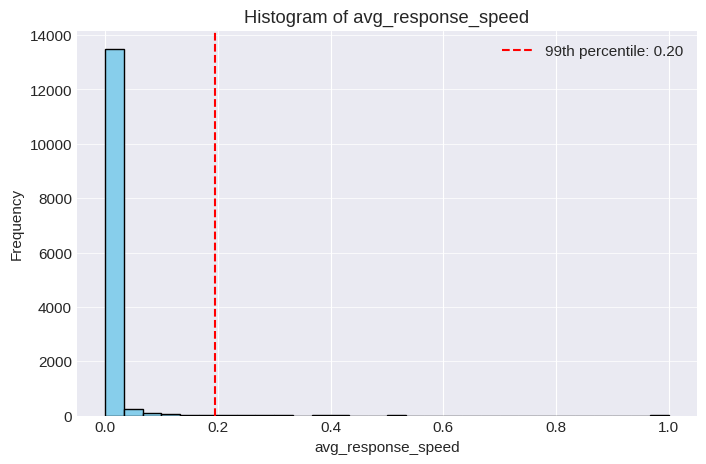

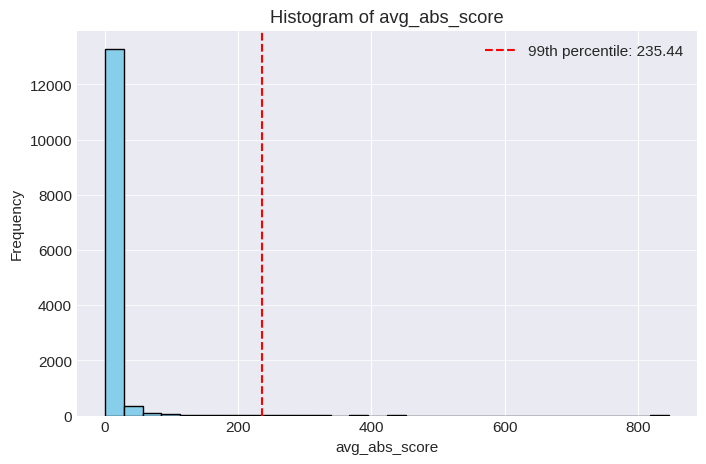

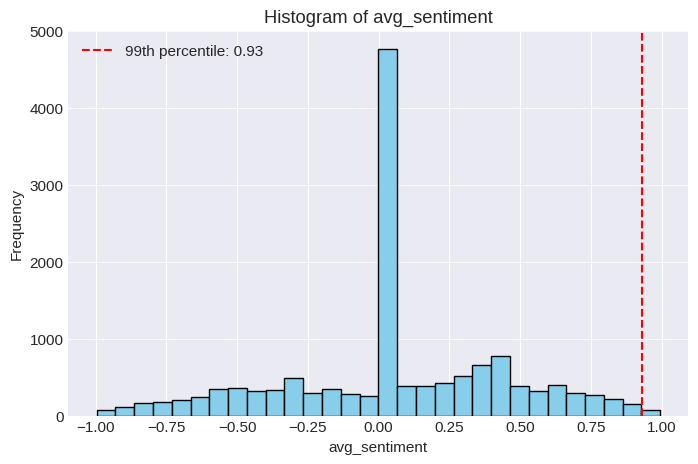

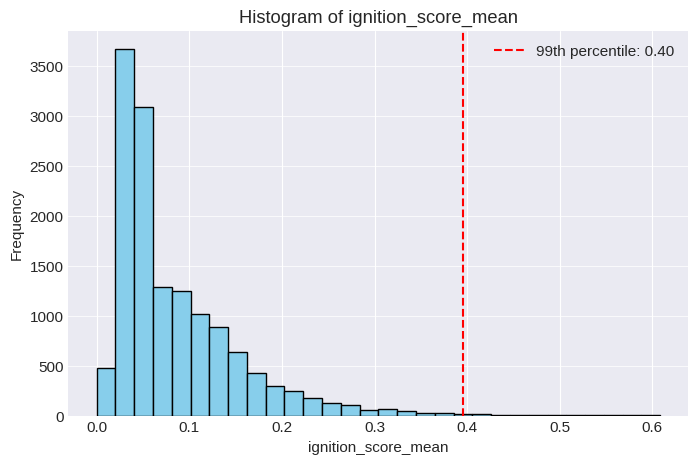

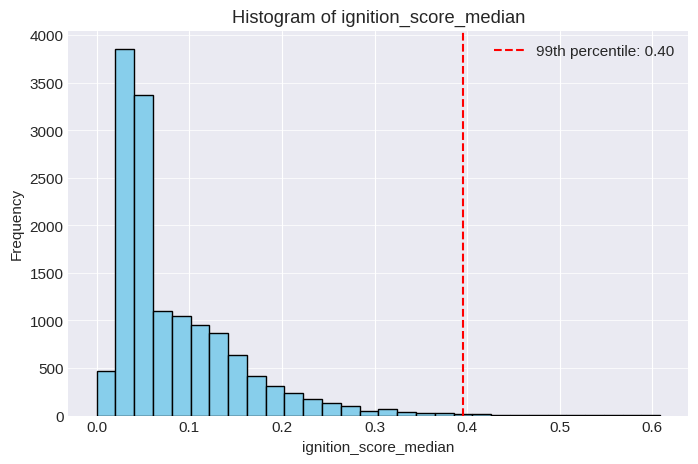

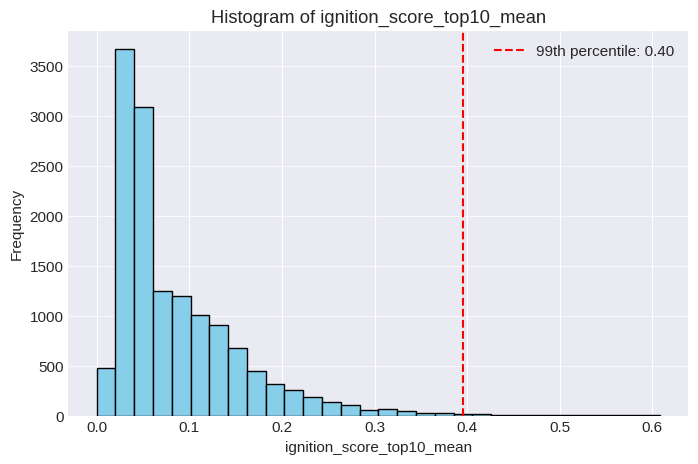

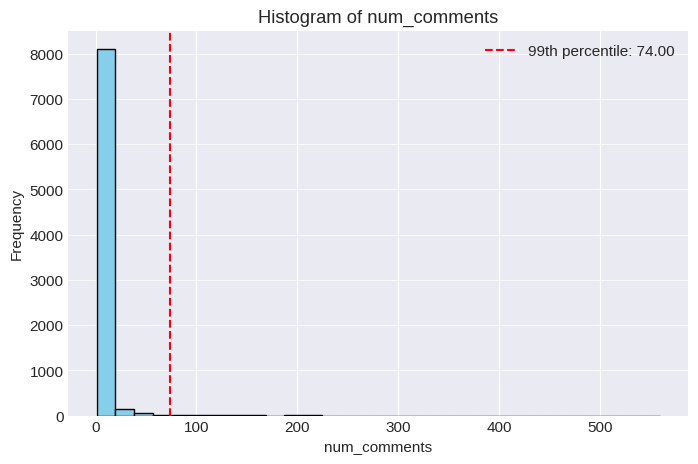

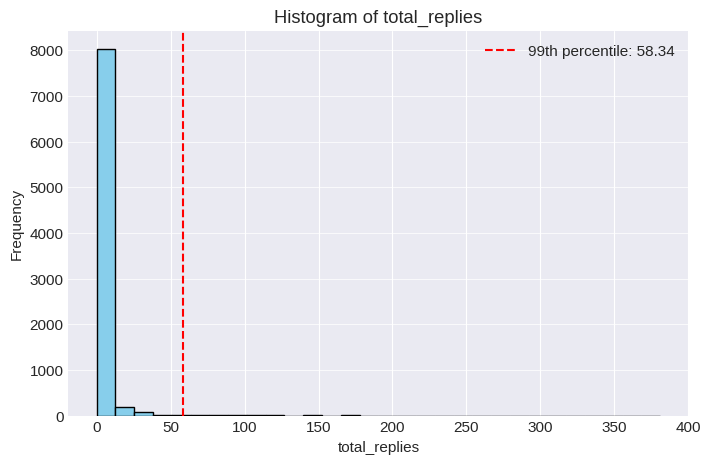

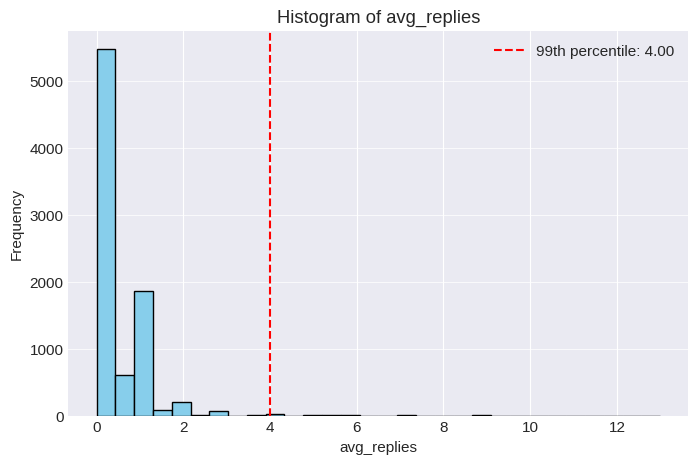

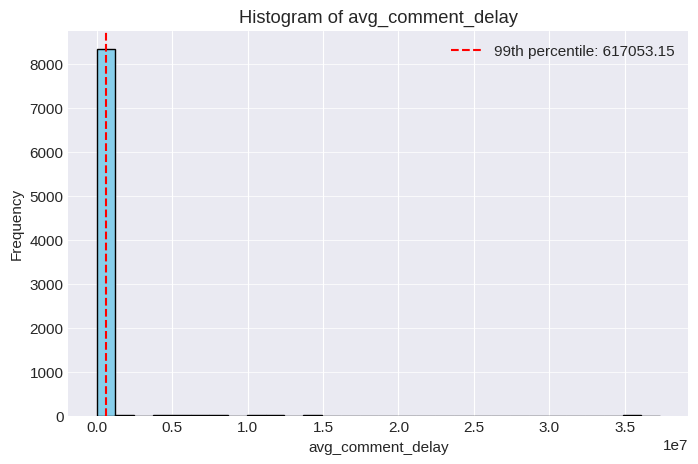

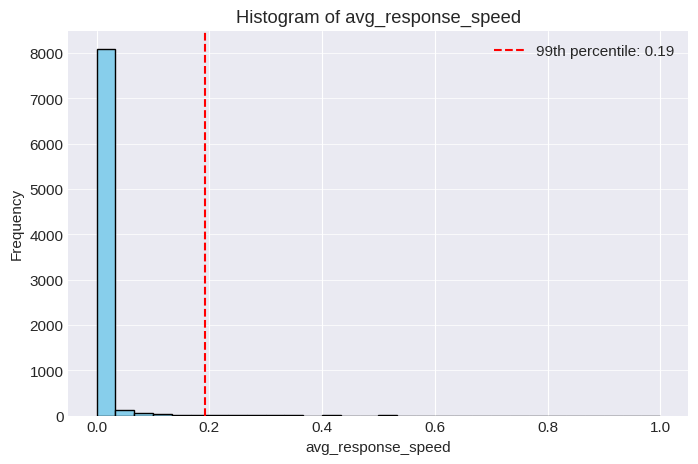

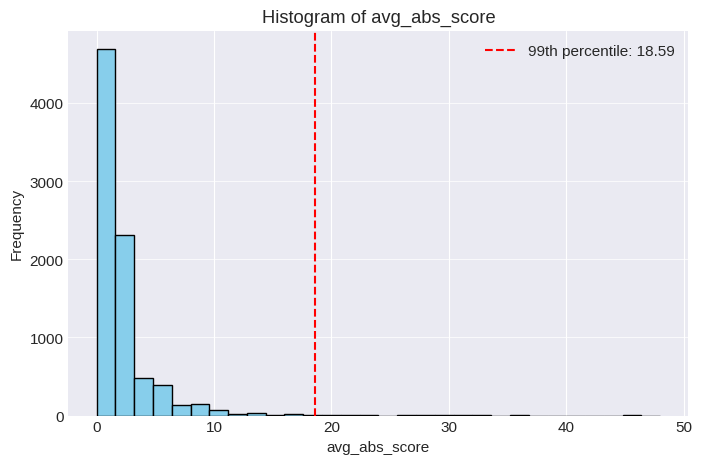

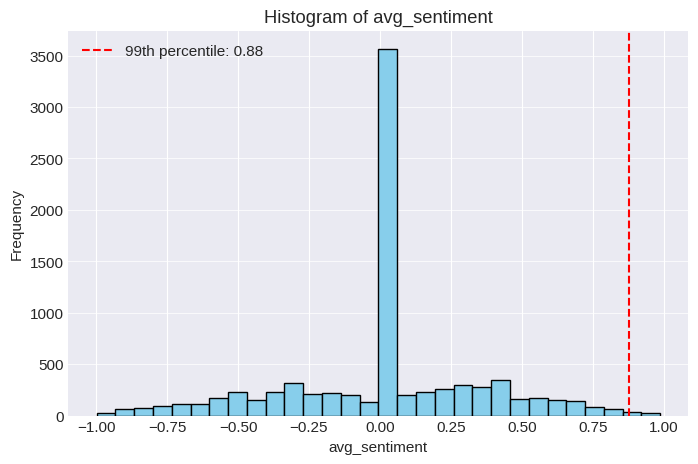

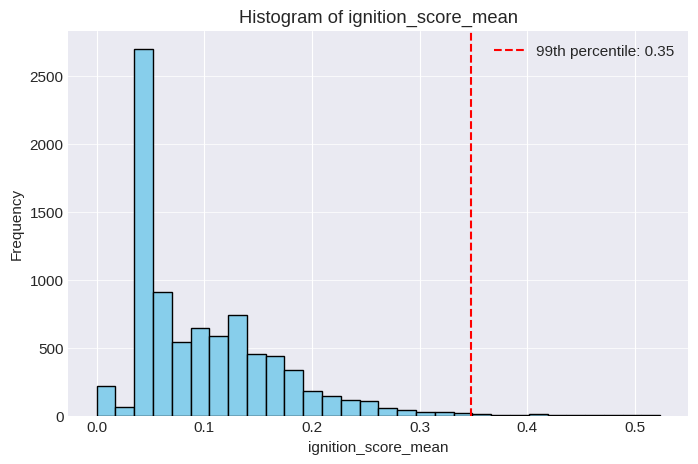

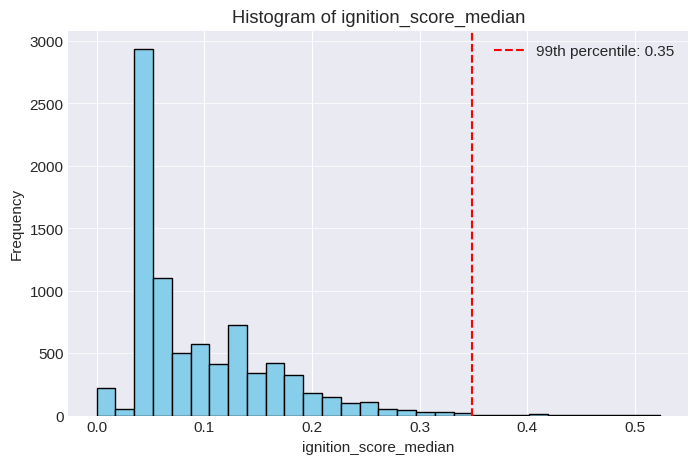

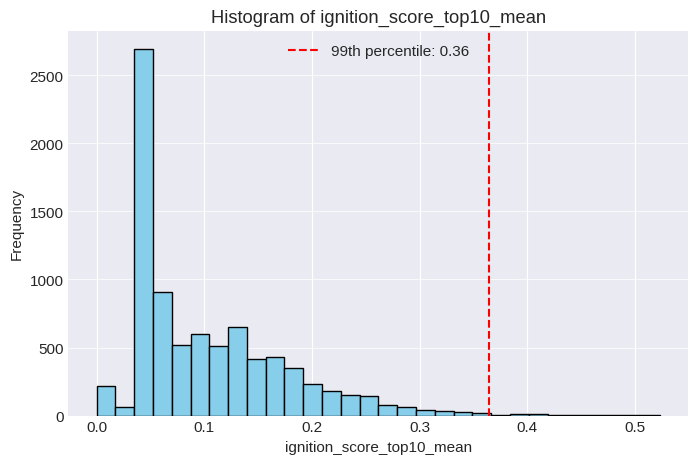

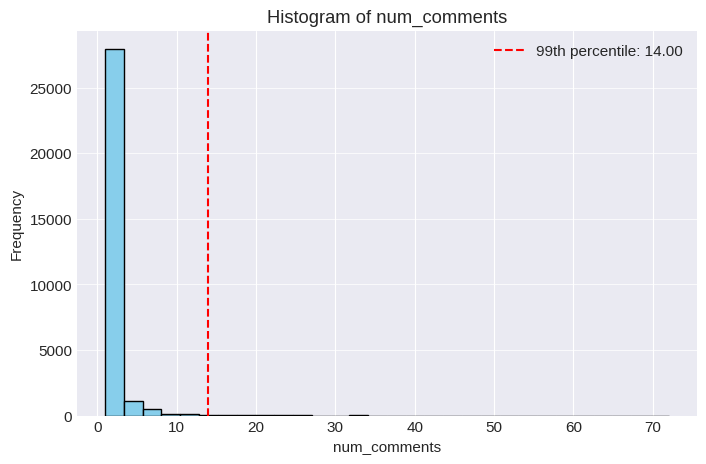

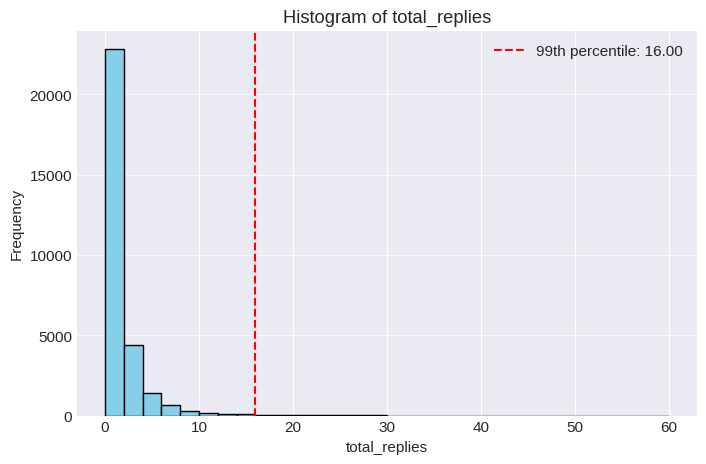

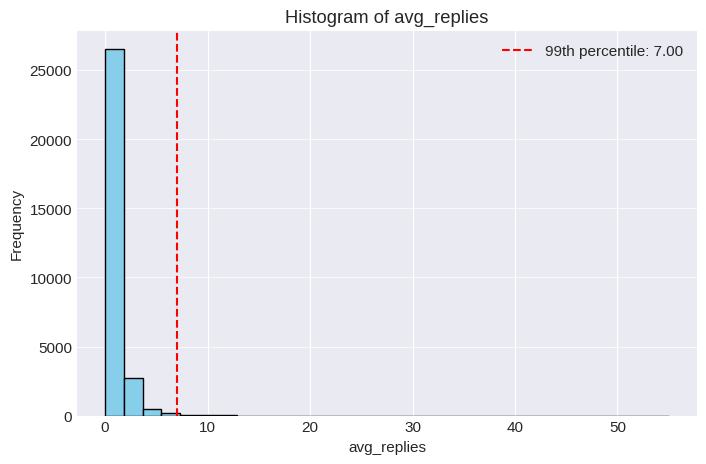

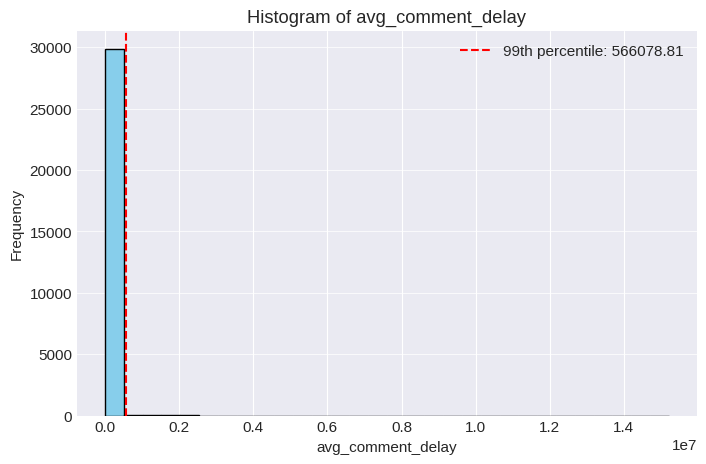

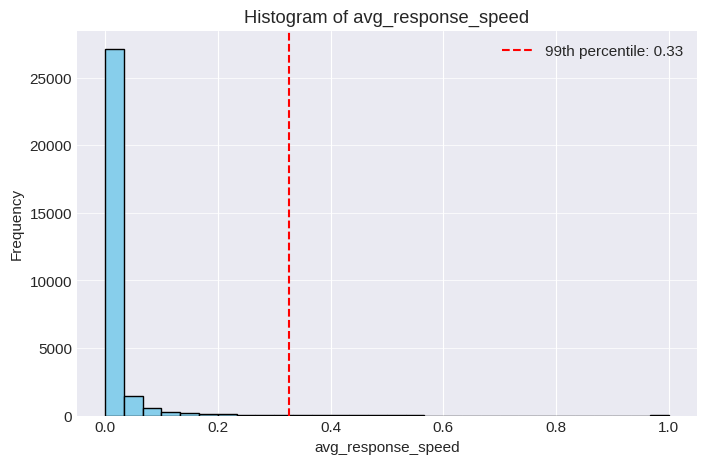

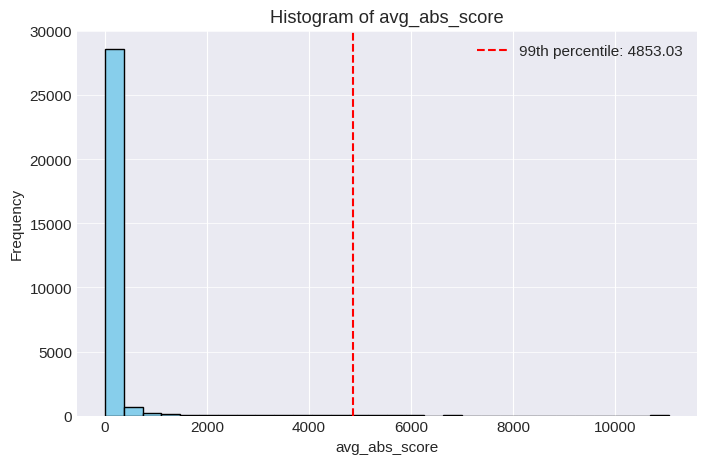

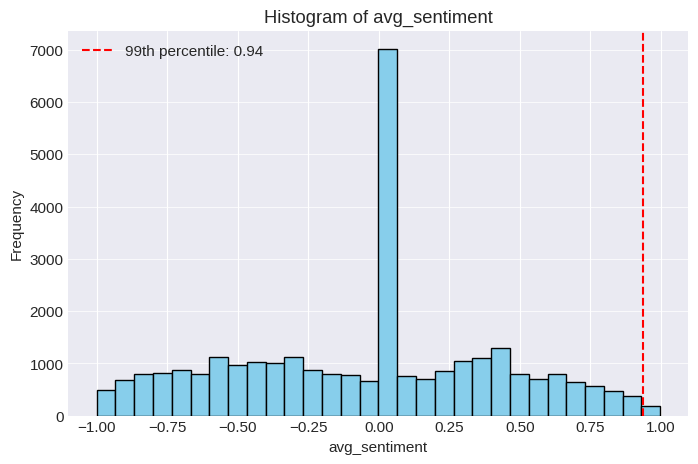

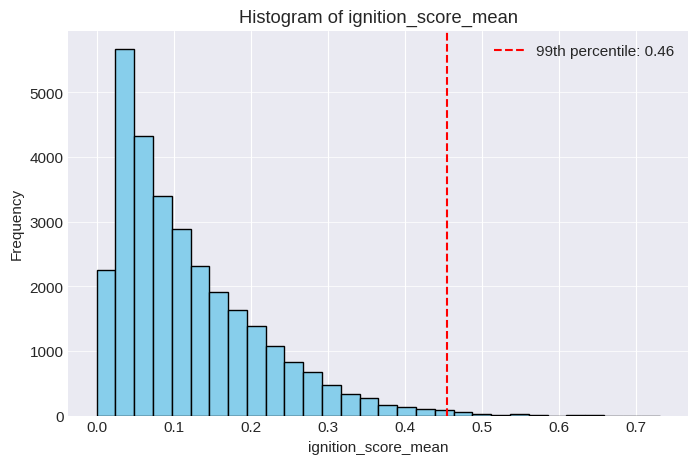

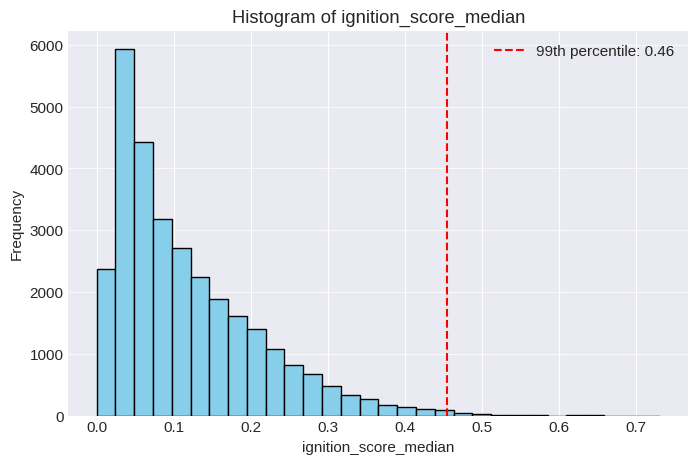

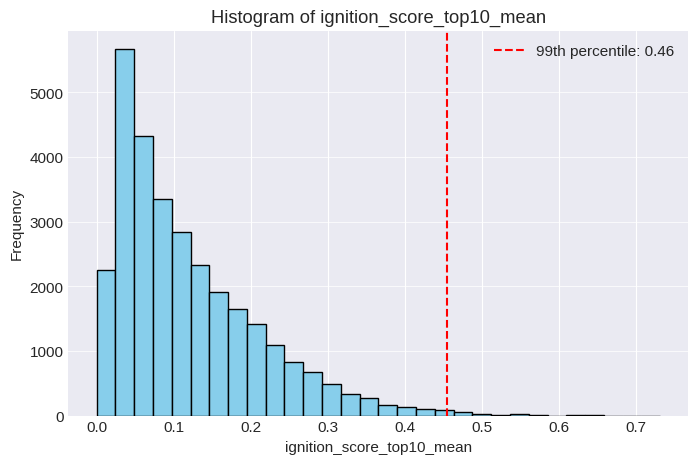

In [96]:
import matplotlib.pyplot as plt

for _users_dict in users_dict.values():
    for col in _users_dict.columns:
        data = _users_dict[col].dropna()
        p99 = data.quantile(0.995)

        plt.figure(figsize=(8, 5))
        plt.hist(data, bins=30, color='skyblue', edgecolor='black')
        plt.axvline(p99, color='red', linestyle='--', label=f'99th percentile: {p99:.2f}')
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.legend()
        plt.grid(axis='y', alpha=0.75)
        plt.show()

In [97]:
winsorize = ['num_comments', 'total_replies', 'avg_replies', 'avg_comment_delay', 'avg_response_speed', 'avg_abs_score']

for name, user_dict in users_dict.items():

    upper = user_dict[winsorize].quantile(0.995)
    user_dict[winsorize] = user_dict[winsorize].clip(upper=upper, axis=1)

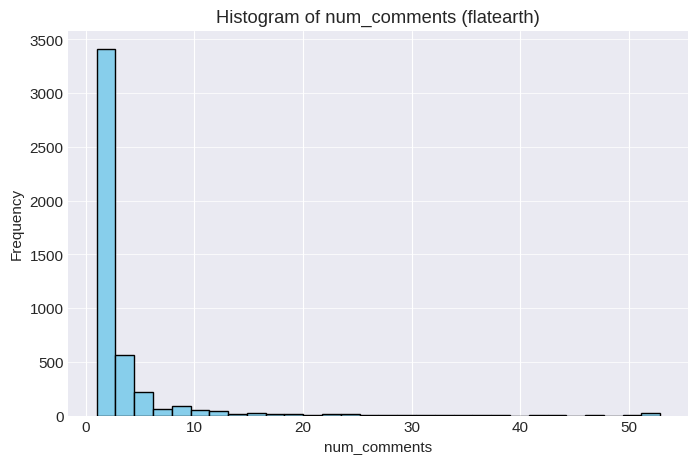

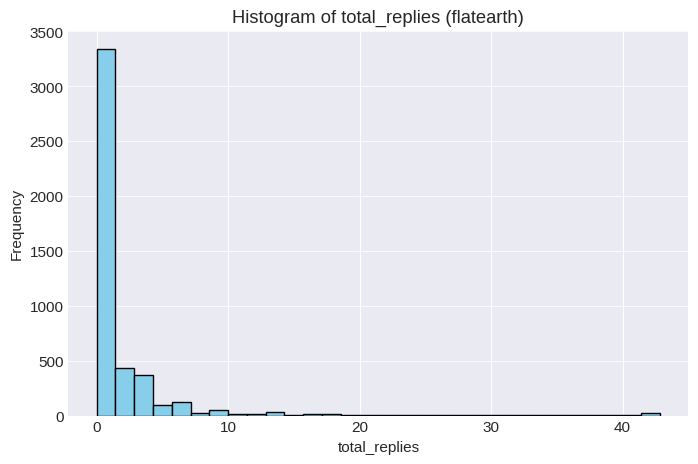

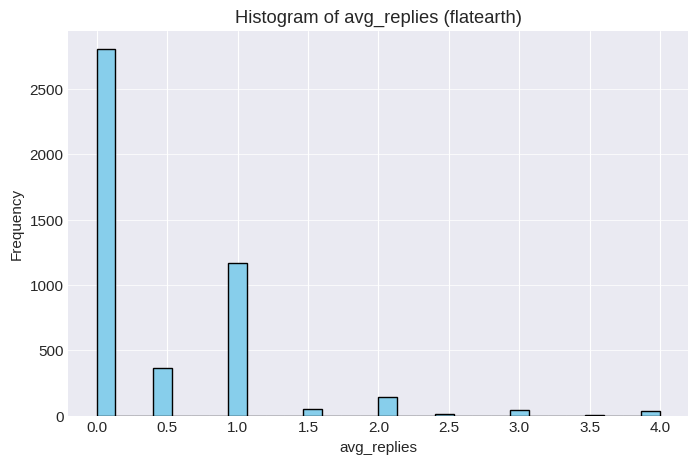

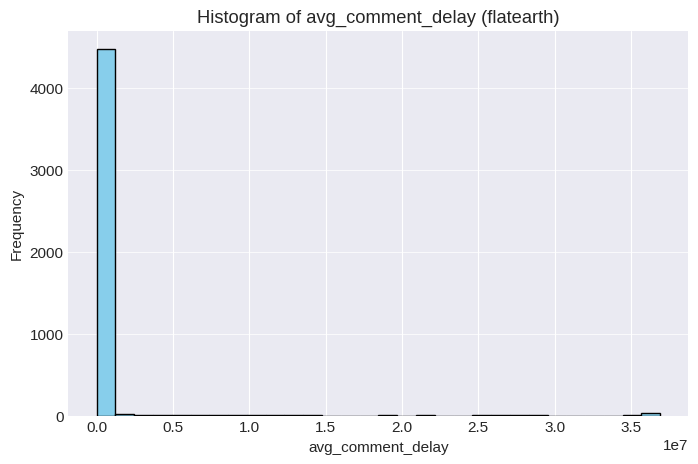

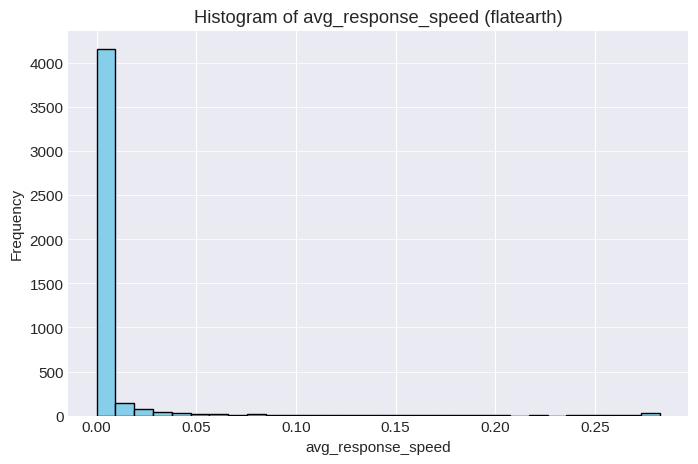

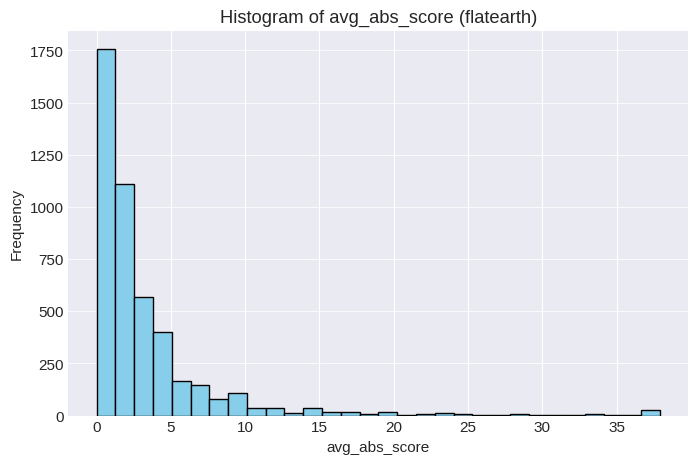

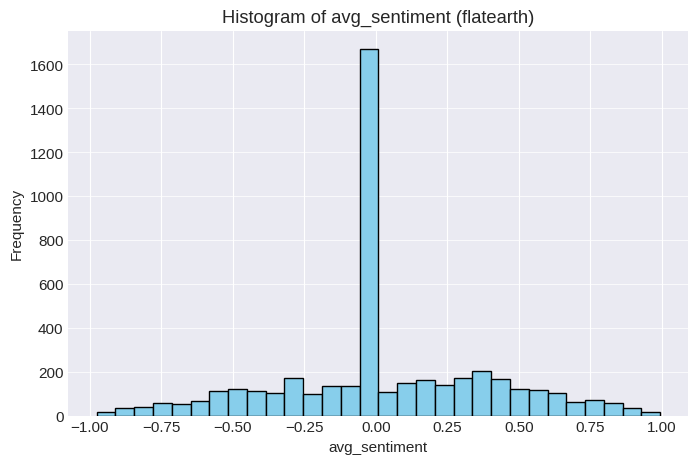

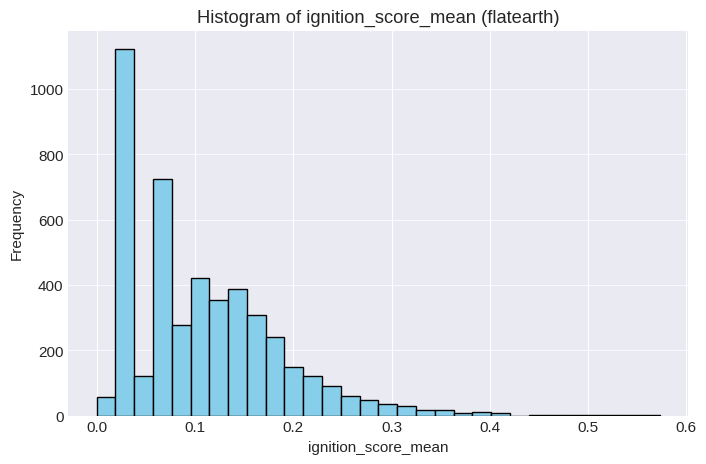

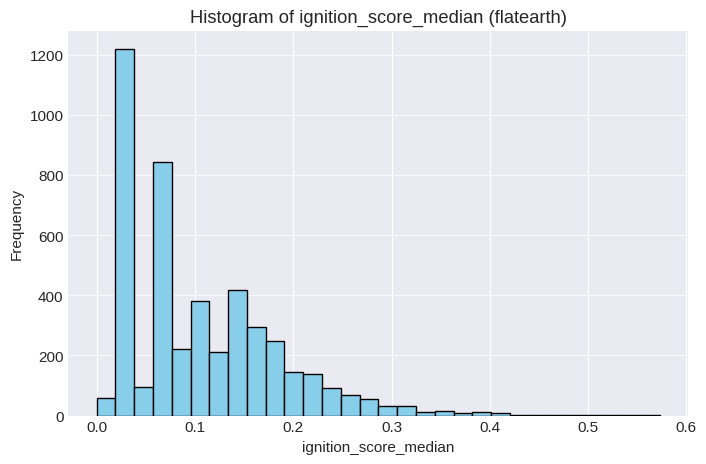

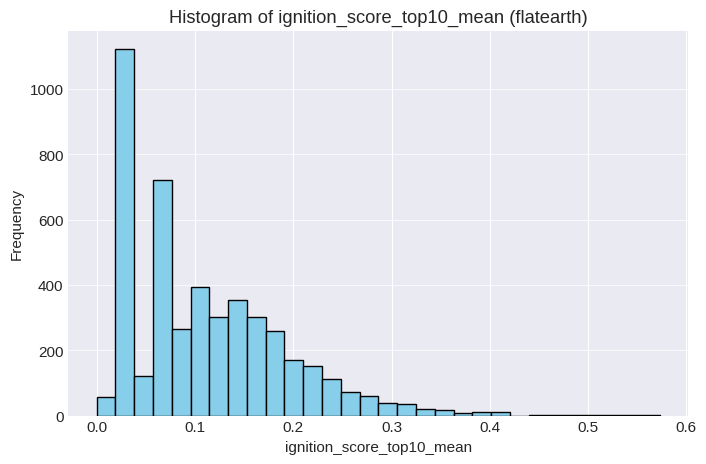

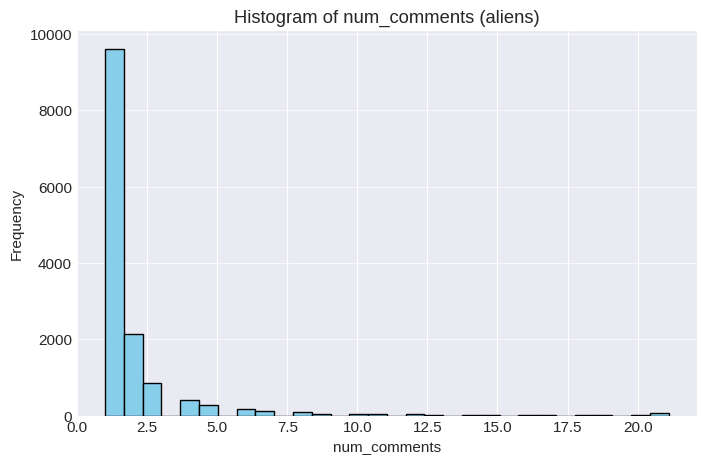

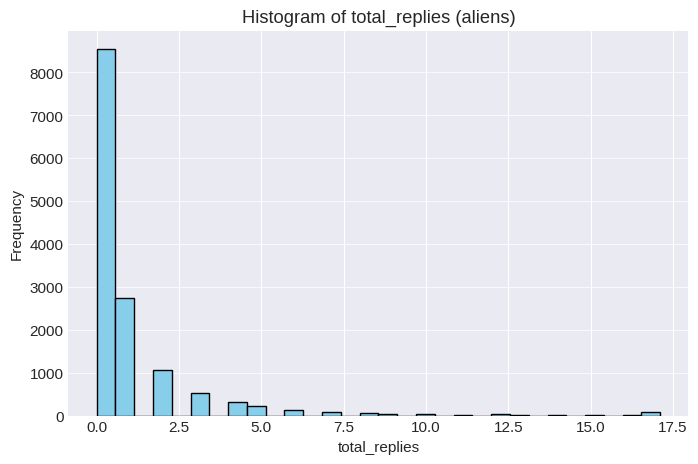

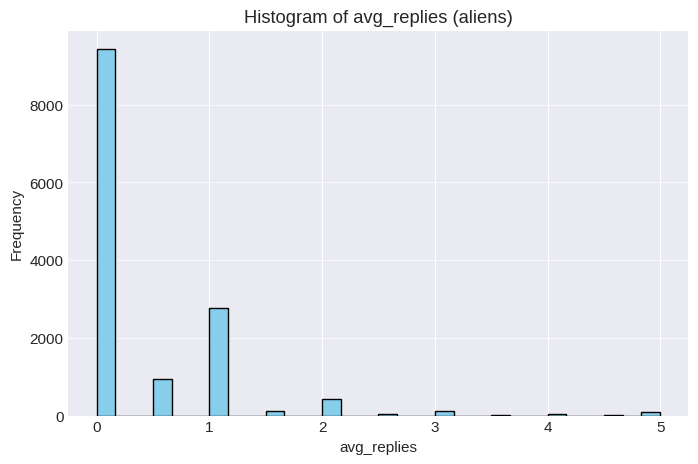

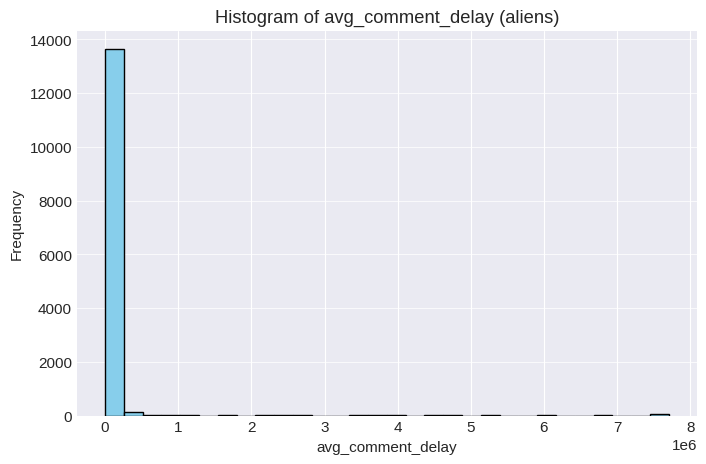

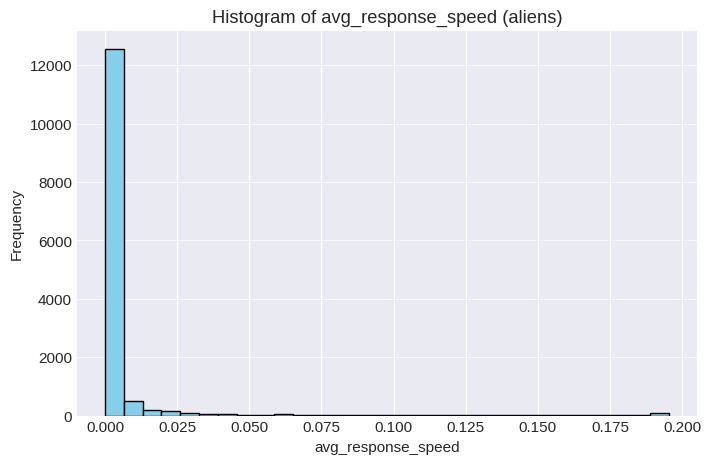

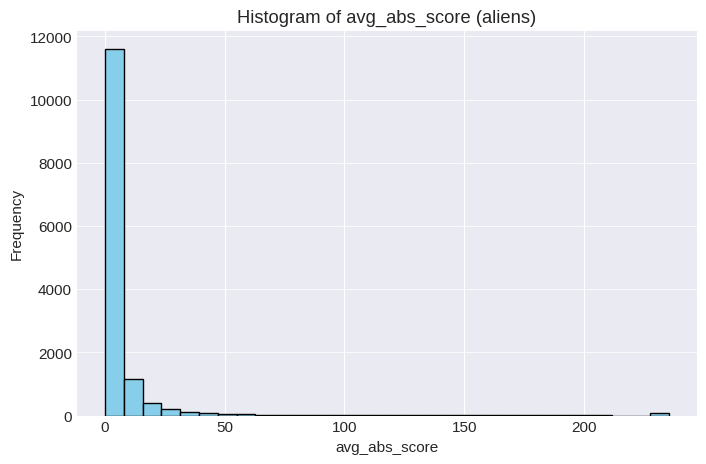

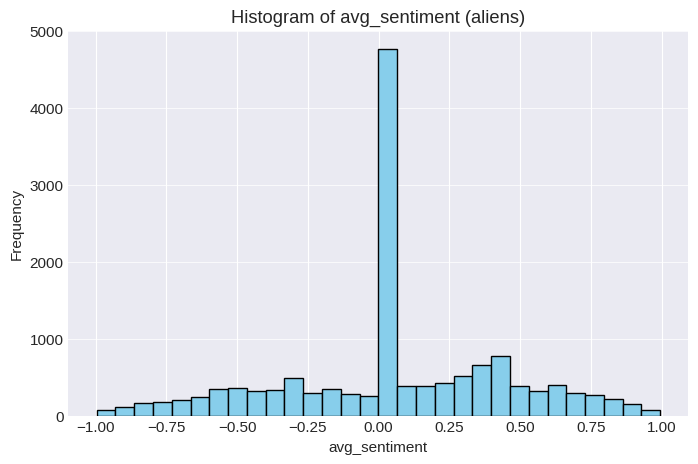

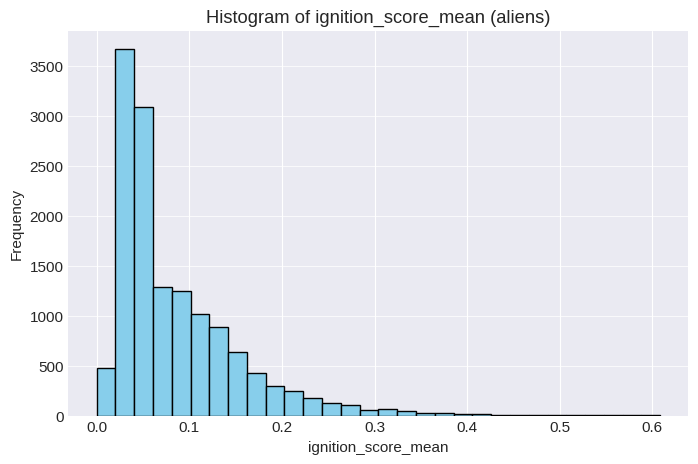

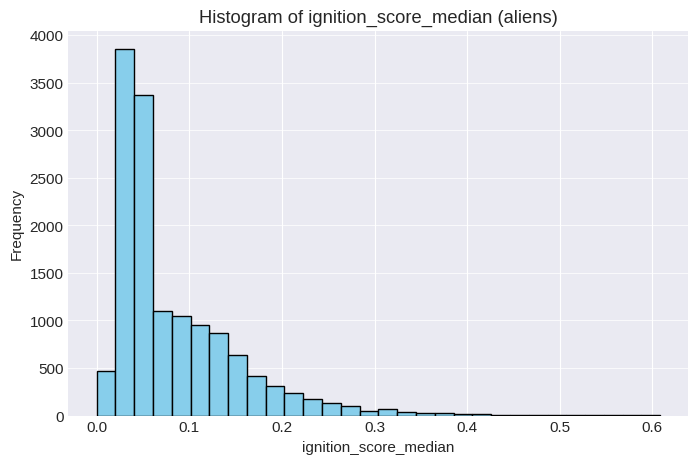

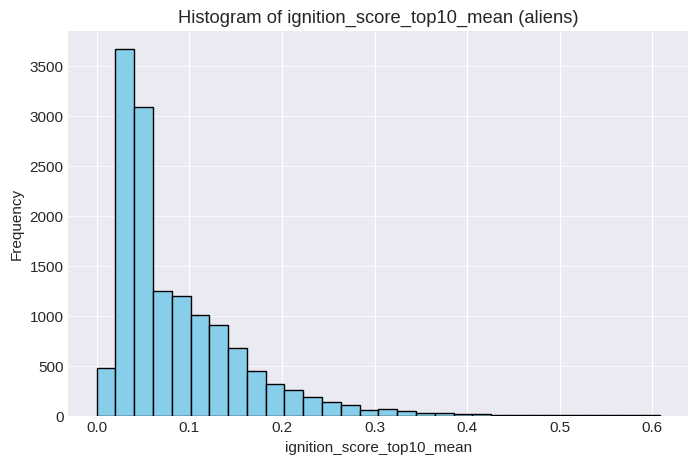

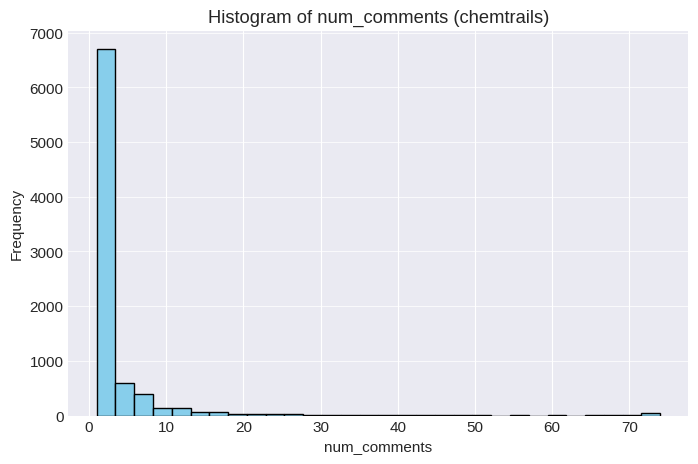

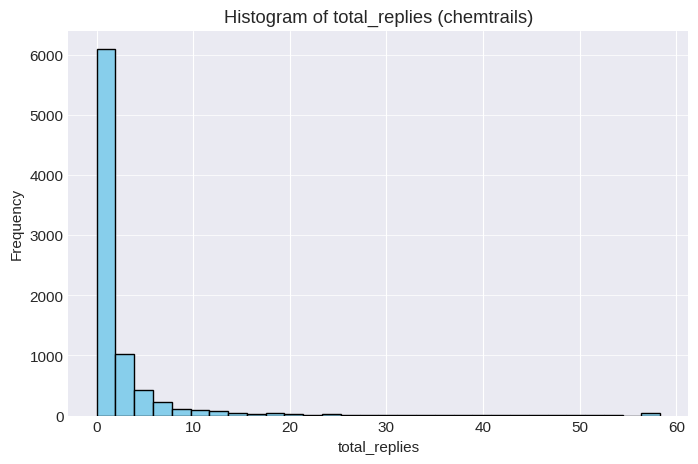

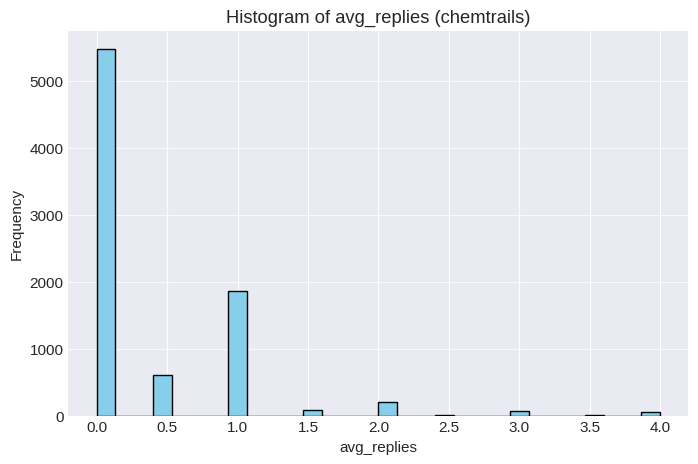

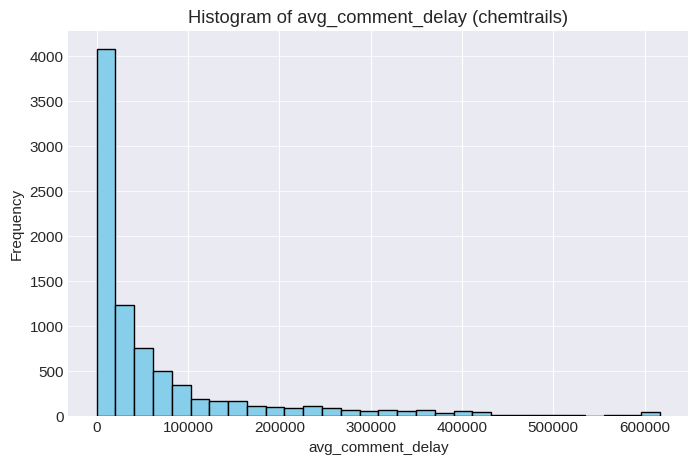

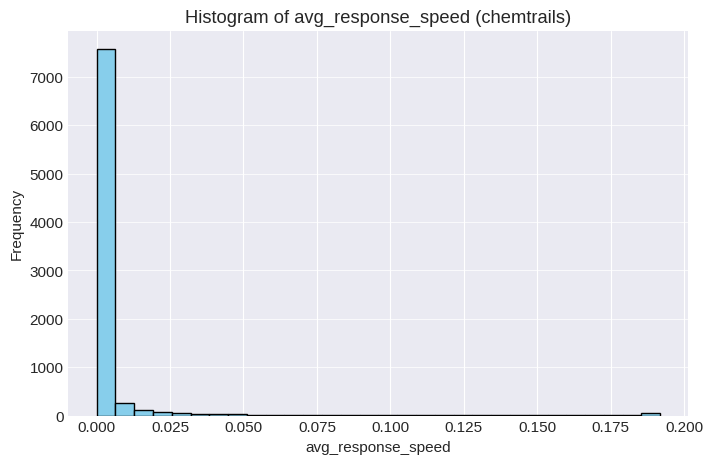

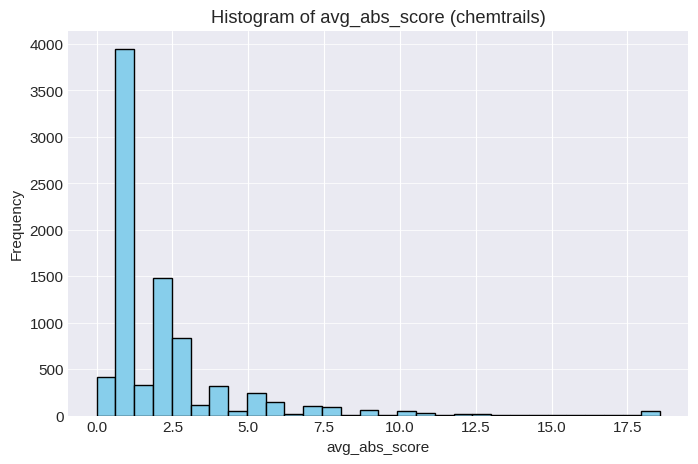

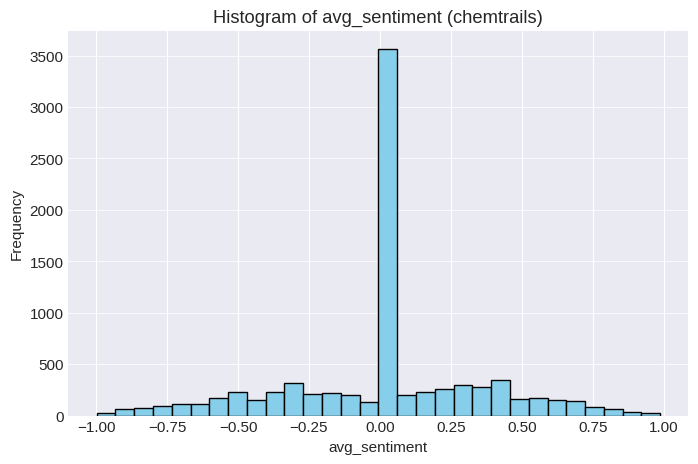

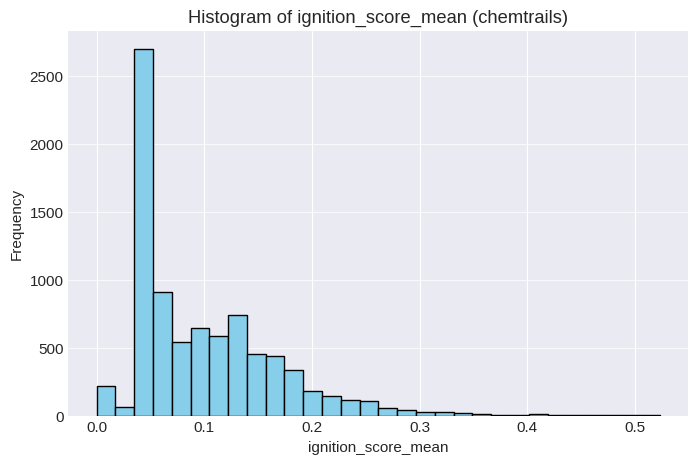

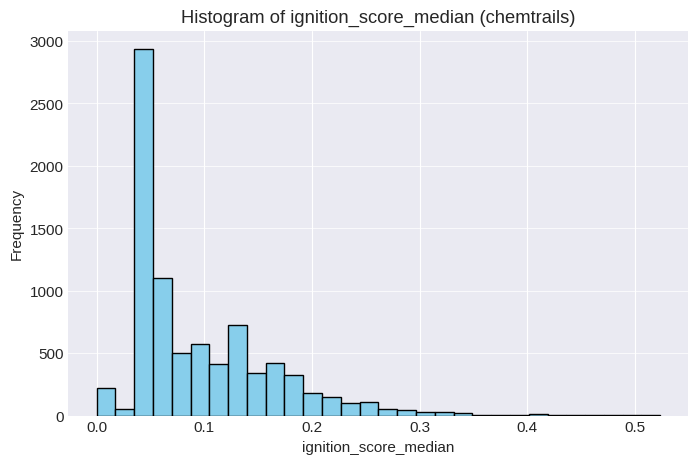

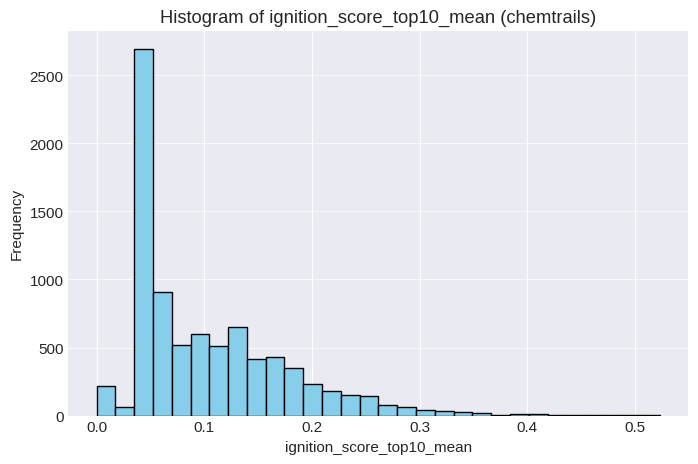

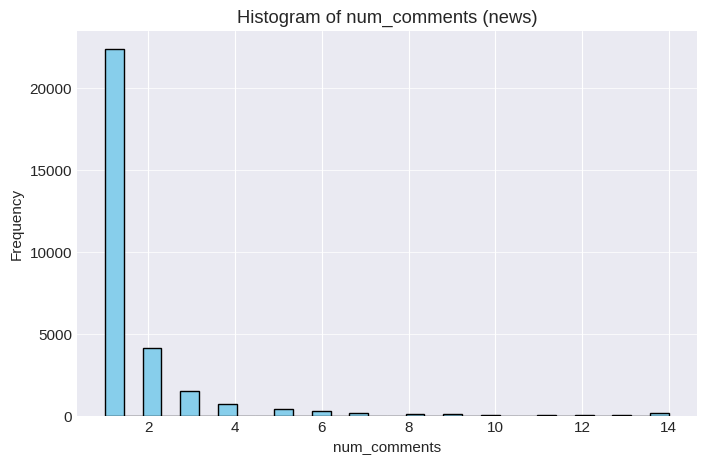

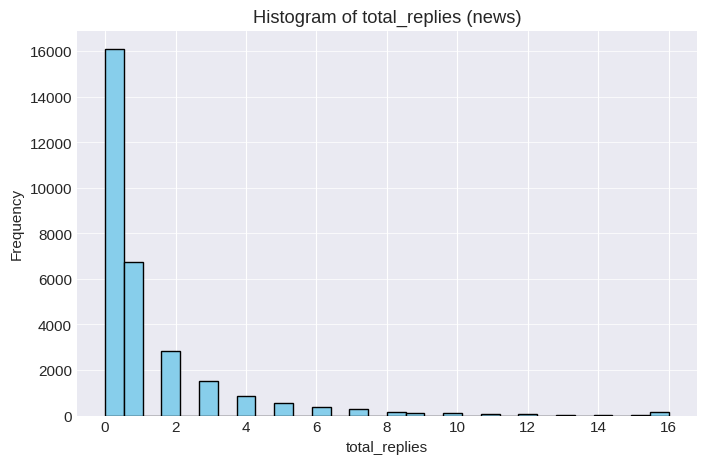

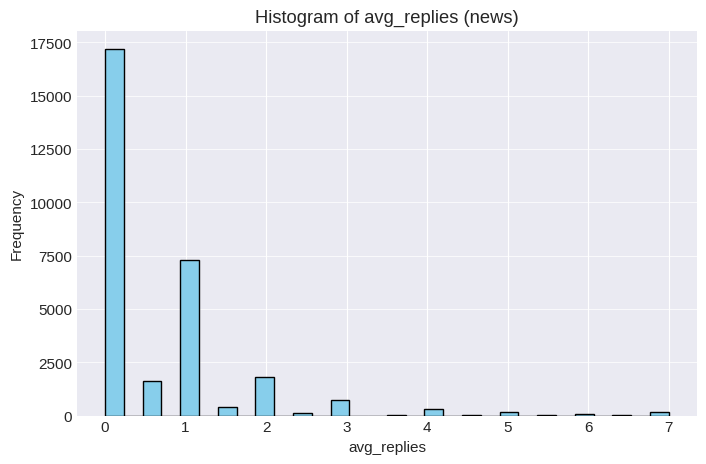

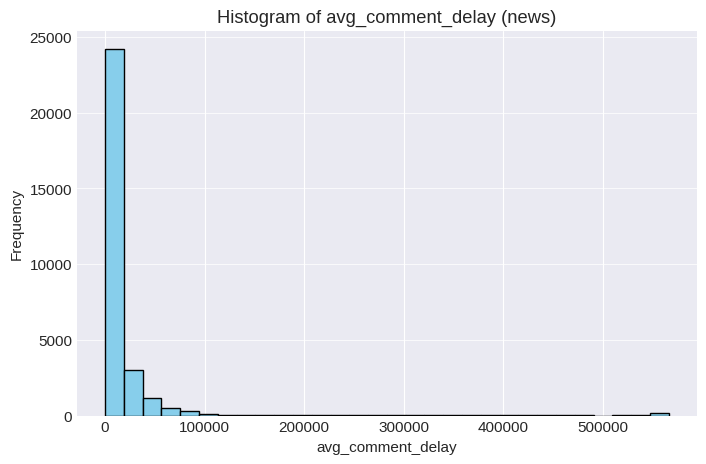

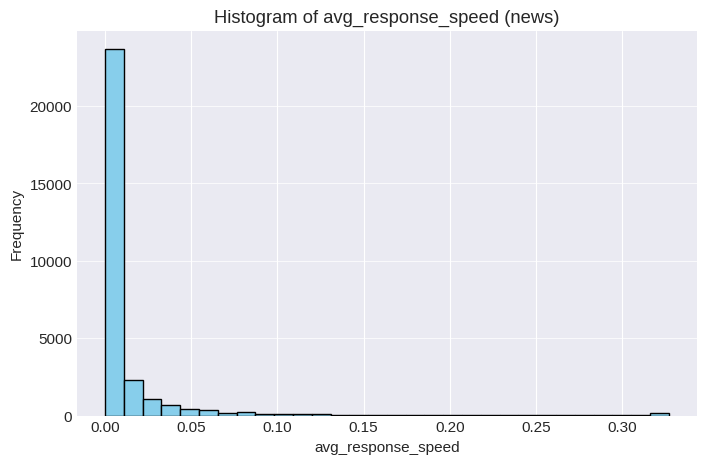

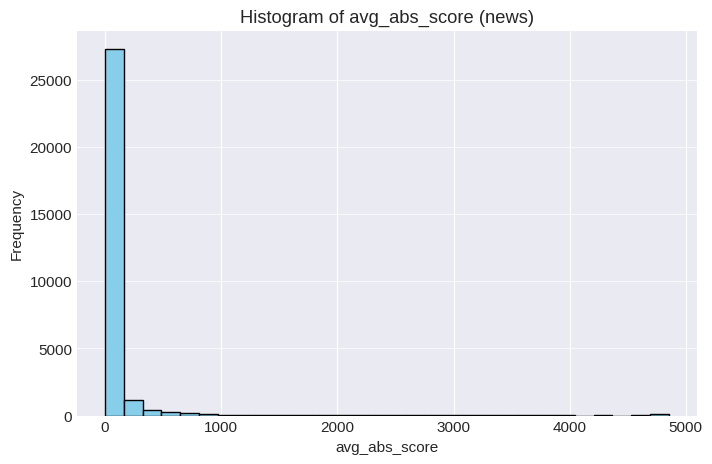

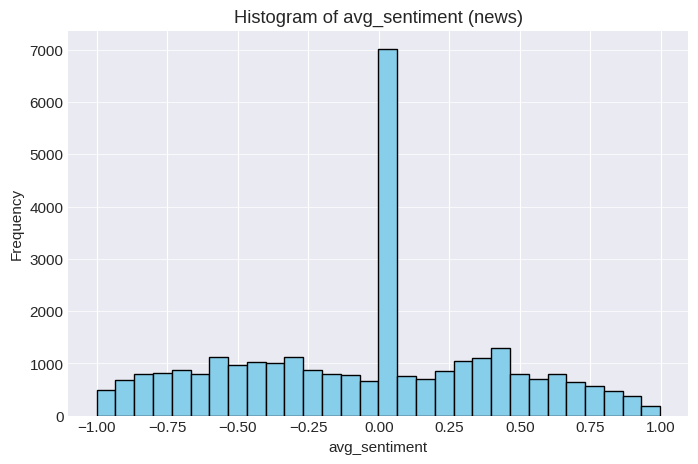

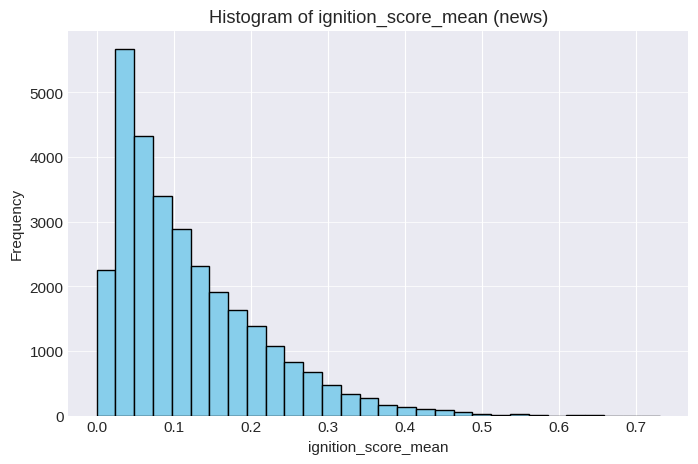

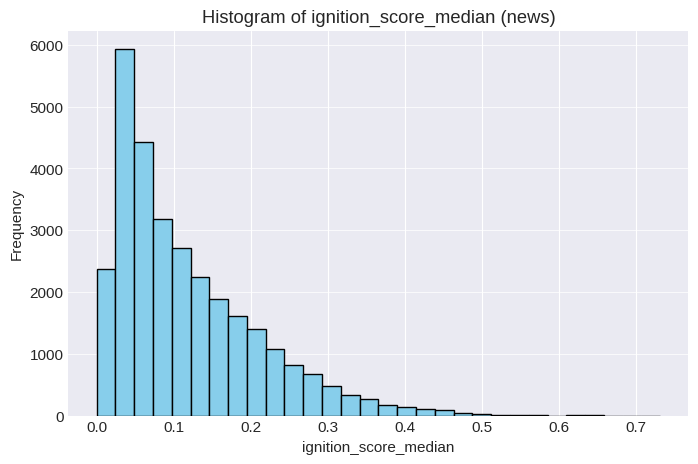

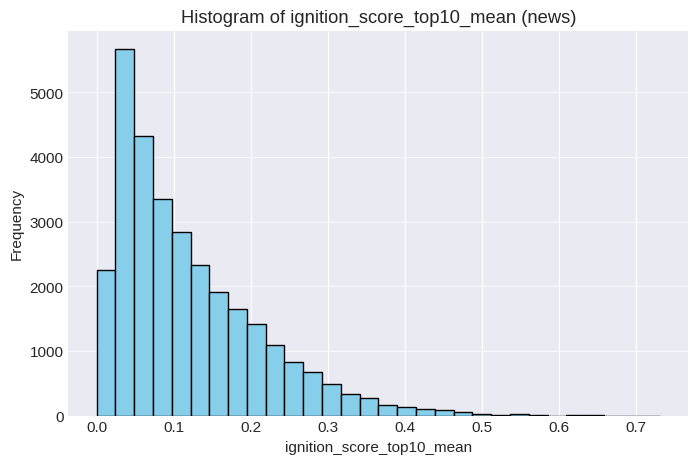

In [100]:
import matplotlib.pyplot as plt

for name, _users_dict in users_dict.items():
  for col in _users_dict.columns:
      plt.figure(figsize=(8, 5))
      plt.hist(_users_dict[col].dropna(), bins=30, color='skyblue', edgecolor='black')
      plt.title(f'Histogram of {col} ({name})')
      plt.xlabel(col)
      plt.ylabel('Frequency')
      plt.grid(axis='y', alpha=0.75)
      plt.show()


## 🎯 ETAP 5: Klasteryzacja Użytkowników (K-Means)

Wykorzystamy wyliczone cechy do identyfikacji ról użytkowników przez grupowanie (clustering).

In [14]:
# Przygotowanie danych do klasteryzacji
print("🎯 Przygotowanie danych do klasteryzacji...")

# Wybór cech do klastrowania
feature_cols = [
    'total_replies', 'num_comments',
    'avg_replies', 'avg_comment_delay', 'avg_response_speed',
    'avg_abs_score', 'avg_sentiment'
]

Xs_dict = {}

for name, user_df in users_dict.items():

    X = user_df[feature_cols].copy()

    if X.isna().any().any():
        raise ValueError(f"NaNs found in features for {name}")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    Xs_dict[name] = X_scaled

    print(f'\n\n{name}')
    print(f"  ✓ Dane przygotowane: {X_scaled.shape[0]} użytkowników × {X_scaled.shape[1]} cech")

🎯 Przygotowanie danych do klasteryzacji...


flatearth
  ✓ Dane przygotowane: 4615 użytkowników × 7 cech


aliens
  ✓ Dane przygotowane: 13979 użytkowników × 7 cech


chemtrails
  ✓ Dane przygotowane: 8367 użytkowników × 7 cech


news
  ✓ Dane przygotowane: 30040 użytkowników × 7 cech


📐 Metoda łokcia dla wyboru liczby klastrów...


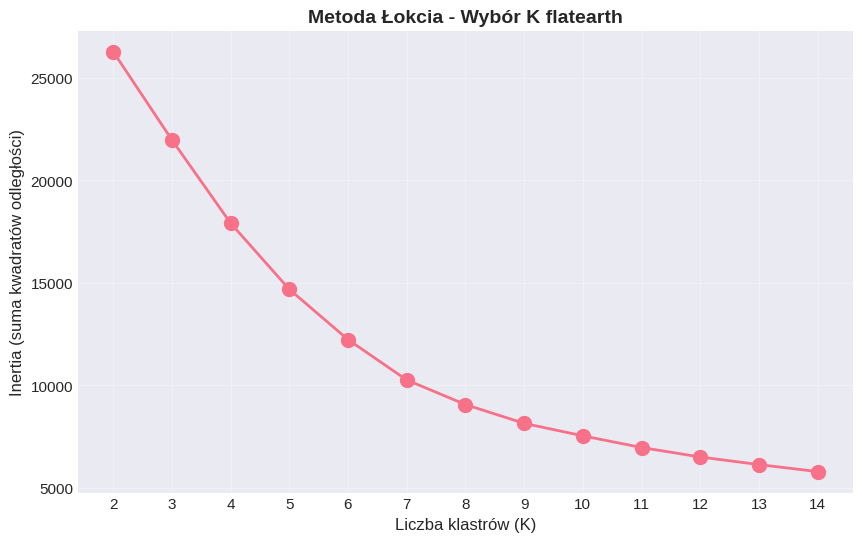

  ℹ️ Szukaj 'łokcia' na wykresie - punkt przegięcia krzywej


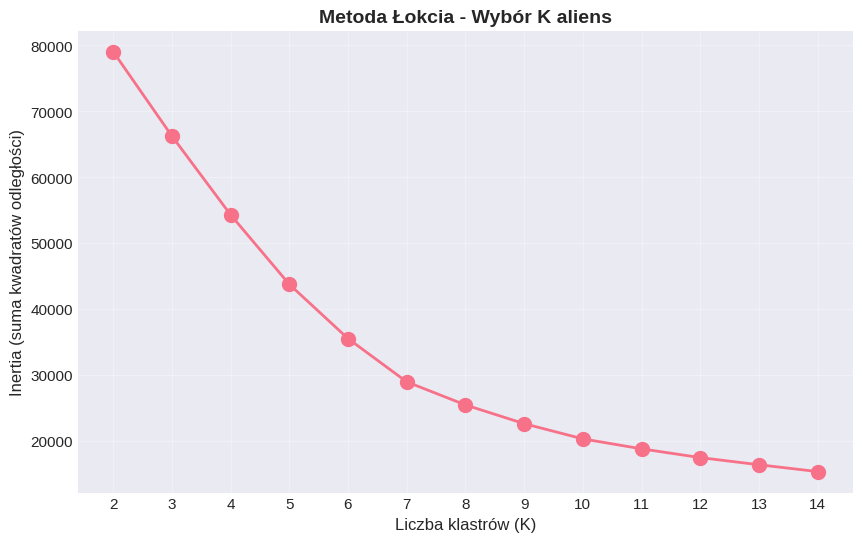

  ℹ️ Szukaj 'łokcia' na wykresie - punkt przegięcia krzywej


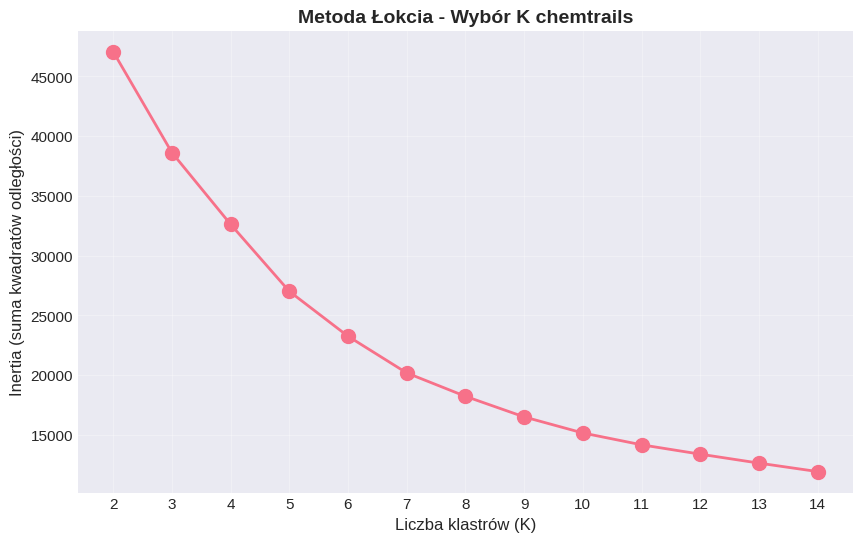

  ℹ️ Szukaj 'łokcia' na wykresie - punkt przegięcia krzywej


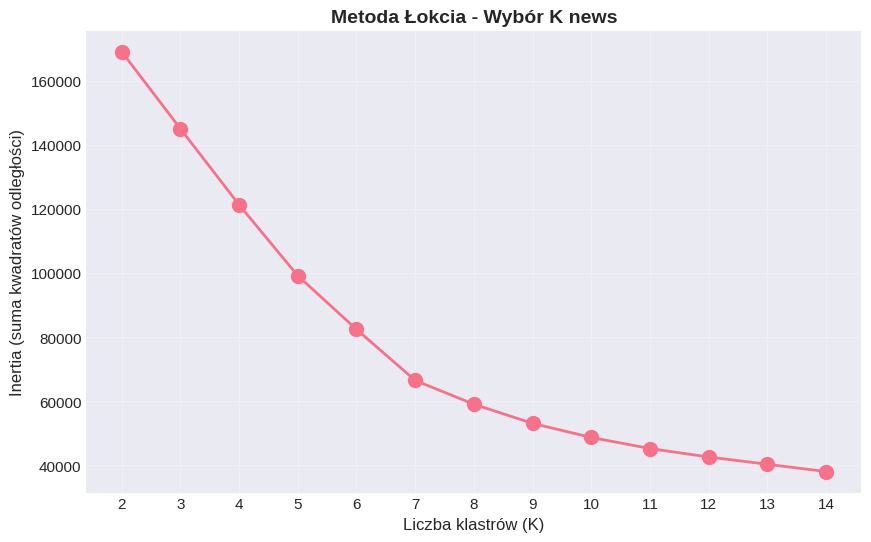

  ℹ️ Szukaj 'łokcia' na wykresie - punkt przegięcia krzywej


In [102]:
# Metoda łokcia - wybór optymalnej liczby klastrów
print("📐 Metoda łokcia dla wyboru liczby klastrów...")

for name, X_scaled in Xs_dict.items():

    inertias = []
    K_range = range(2, 15)

    for k in K_range:
        kmeans_temp = KMeans(n_clusters=k, random_state=132, n_init=50)
        kmeans_temp.fit(X_scaled)
        inertias.append(kmeans_temp.inertia_)

    plt.figure(figsize=(10, 6))
    plt.plot(K_range, inertias, marker='o', linewidth=2, markersize=10)
    plt.xlabel('Liczba klastrów (K)', fontsize=12)
    plt.ylabel('Inertia (suma kwadratów odległości)', fontsize=12)
    plt.title(f'Metoda Łokcia - Wybór K {name}', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.xticks(K_range)
    plt.show()

    print("  ℹ️ Szukaj 'łokcia' na wykresie - punkt przegięcia krzywej")

In [15]:
print("🔬 Uruchomienie K-Means (K=7)...")

n_clusters = 7
kmeans_dict = {}

for name, user_df in users_dict.items():
    X_scaled = Xs_dict[name]
    kmeans = KMeans(n_clusters=n_clusters, random_state=123)
    user_df['cluster'] = kmeans.fit_predict(X_scaled)
    kmeans_dict[name] = kmeans

    print(f'\n\n{name}')
    print(f"  ✓ Klasteryzacja zakończona")
    print(f"\n📊 Rozkład użytkowników w klastrach:")
    print(user_df['cluster'].value_counts().sort_index())

🔬 Uruchomienie K-Means (K=7)...


flatearth
  ✓ Klasteryzacja zakończona

📊 Rozkład użytkowników w klastrach:
cluster
0      42
1    1659
2    2620
3       9
4      18
5     148
6     119
Name: count, dtype: int64


aliens
  ✓ Klasteryzacja zakończona

📊 Rozkład użytkowników w klastrach:
cluster
0    2113
1    8526
2      55
3     133
4    3072
5       2
6      78
Name: count, dtype: int64


chemtrails
  ✓ Klasteryzacja zakończona

📊 Rozkład użytkowników w klastrach:
cluster
0    5967
1      29
2     487
3       3
4      83
5    1781
6      17
Name: count, dtype: int64


news
  ✓ Klasteryzacja zakończona

📊 Rozkład użytkowników w klastrach:
cluster
0     8561
1      190
2    15946
3      503
4     4347
5       30
6      463
Name: count, dtype: int64


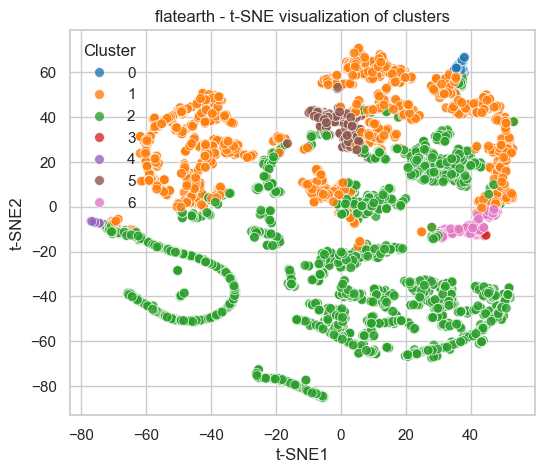

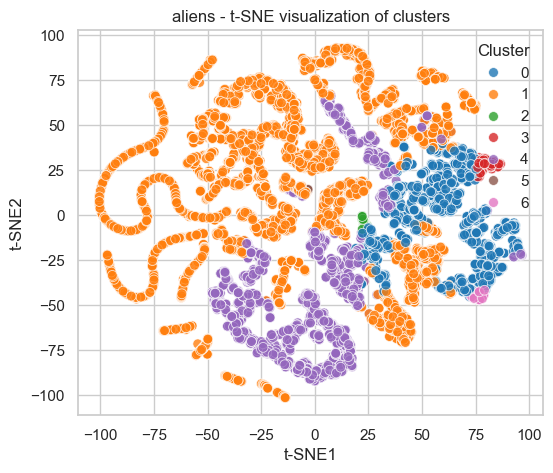

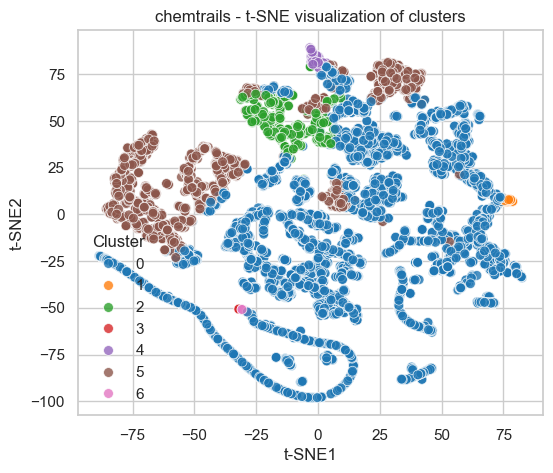

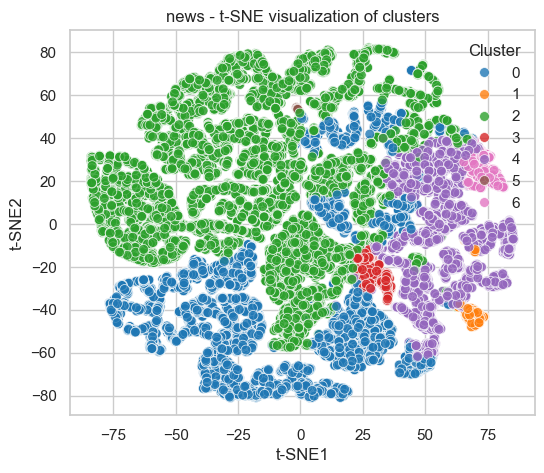

In [18]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

for name, X_scaled in Xs_dict.items():
    user_df = users_dict[name]

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate=200,
        random_state=123,
    )
    X_tsne = tsne.fit_transform(X_scaled)

    plt.figure(figsize=(6,5))
    sns.scatterplot(
        x=X_tsne[:,0],
        y=X_tsne[:,1],
        hue=user_df['cluster'],
        palette='tab10',
        s=50,
        alpha=0.8
    )
    plt.title(f"{name} - t-SNE visualization of clusters")
    plt.xlabel("t-SNE1")
    plt.ylabel("t-SNE2")
    plt.legend(title='Cluster')
    plt.show()


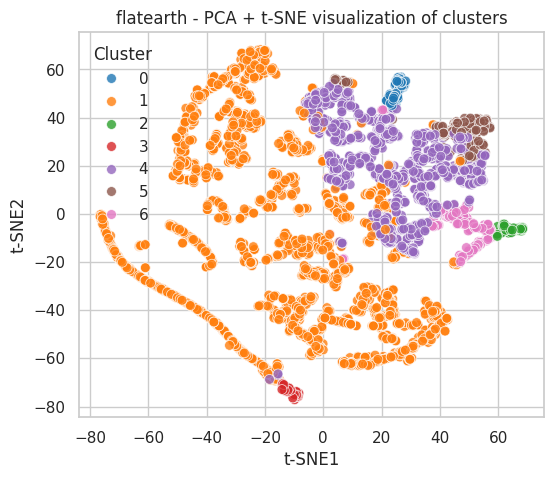

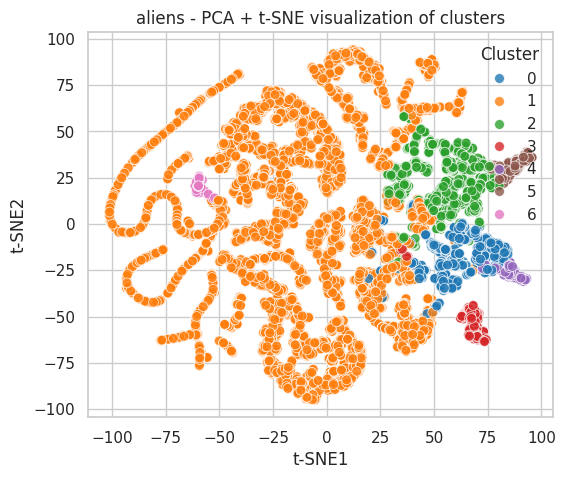

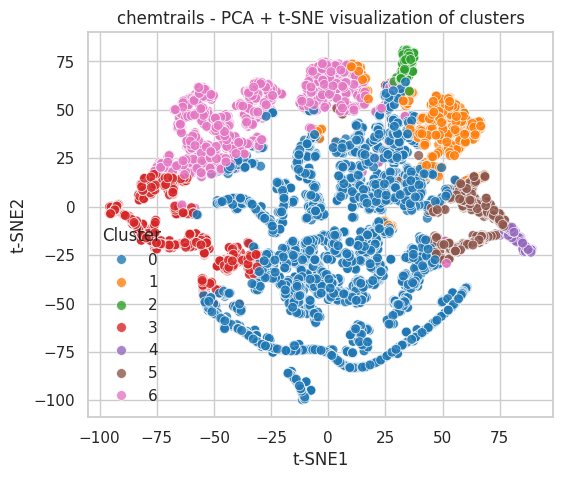

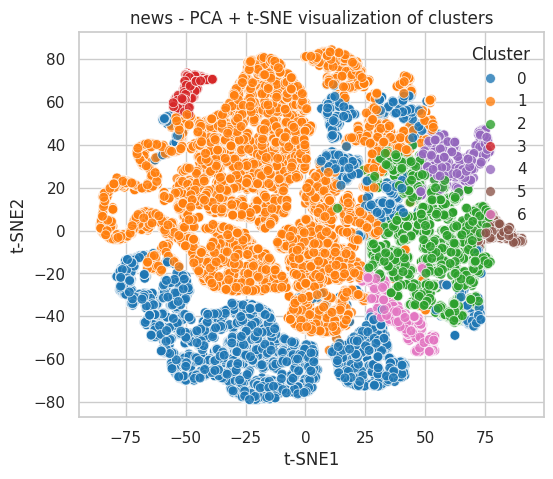

In [105]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

for name, X_scaled in Xs_dict.items():
    user_df = users_dict[name]

    X_pca = PCA(n_components=5, random_state=123).fit_transform(X_scaled)

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate=200,
        random_state=123,
        init='pca'
    )
    X_tsne = tsne.fit_transform(X_pca)

    plt.figure(figsize=(6,5))
    sns.scatterplot(
        x=X_tsne[:,0],
        y=X_tsne[:,1],
        hue=user_df['cluster'],
        palette='tab10',
        s=50,
        alpha=0.8
    )
    plt.title(f"{name} - PCA + t-SNE visualization of clusters")
    plt.xlabel("t-SNE1")
    plt.ylabel("t-SNE2")
    plt.legend(title='Cluster')
    plt.show()


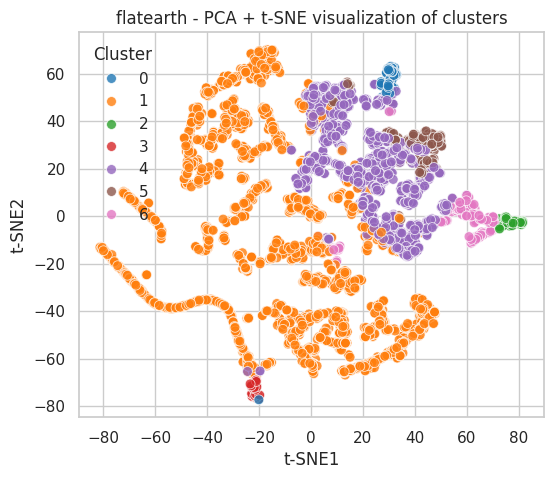

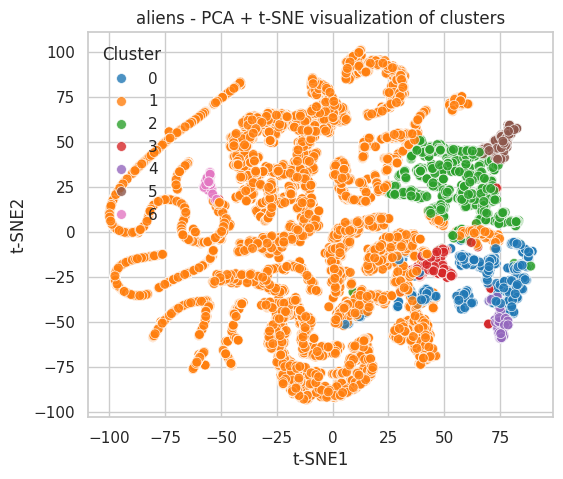

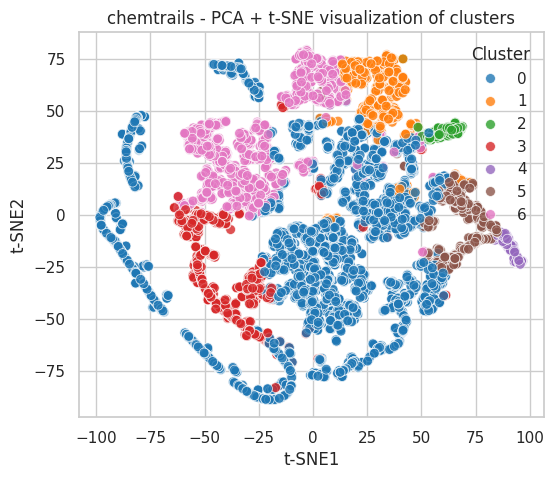

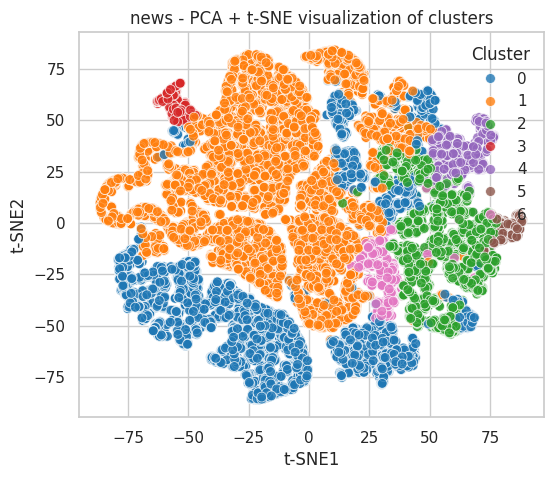

In [106]:
sns.set(style="whitegrid")

for name, X_scaled in Xs_dict.items():
    user_df = users_dict[name]

    X_pca = PCA(n_components=4, random_state=123).fit_transform(X_scaled)

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate=200,
        random_state=123,
        init='pca'
    )
    X_tsne = tsne.fit_transform(X_pca)

    plt.figure(figsize=(6,5))
    sns.scatterplot(
        x=X_tsne[:,0],
        y=X_tsne[:,1],
        hue=user_df['cluster'],
        palette='tab10',
        s=50,
        alpha=0.8
    )
    plt.title(f"{name} - PCA + t-SNE visualization of clusters")
    plt.xlabel("t-SNE1")
    plt.ylabel("t-SNE2")
    plt.legend(title='Cluster')
    plt.show()


In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cluster_stats_dict = {}

ignition_cols = ['ignition_score_mean', 'ignition_score_median', 'ignition_score_top10_mean']
all_cols_to_agg = feature_cols + ignition_cols

for name, user_df in users_dict.items():
    df = user_df.copy()

    for col in ignition_cols:
        min_val = df[col].min()
        max_val = df[col].max()
        if max_val > min_val:
            df[col] = (df[col] - min_val) / (max_val - min_val)
        else:
            df[col] = 0.0

    stats = (
        user_df.groupby('cluster')[all_cols_to_agg]
        .agg(['mean', 'std', 'median', 'min', 'max', 'count'])
        .round(2)
    )
    cluster_stats_dict[name] = stats


In [144]:
cluster_stats_dict['flatearth']

total_replies                                 num_comments         \
                 mean   std median   min    max count         mean    std   
cluster                                                                     
0                1.57  1.18    1.0   1.0   8.00    83         1.72   1.09   
1                0.34  0.81    0.0   0.0   9.00  2900         1.81   1.65   
2               34.45  9.21   38.5  17.0  42.86    62        40.72  12.86   
3                0.30  0.95    0.0   0.0   6.00    53         1.72   1.96   
4                2.51  1.94    2.0   1.0  14.00  1141         2.45   1.94   
5                2.62  3.63    2.0   0.0  28.00   169         1.46   1.07   
6               11.55  4.91   11.0   3.0  30.00   207        16.19   6.56   

                     ... ignition_score_median                    \
        median  min  ...                median   min   max count   
cluster              ...                                           
0          1.0  1.0  ...                  0.21  0.11  0.50    83   
1          1.0  1.0  ...                  0.06  0.00  0.20  2900   
2         43.0  9.0  ...                  0.14  0.06  0.39    62   
3          1.0  1.0  ...                  0.04  0.00  0.17    53   
4          2.0  1.0  ...                  0.17  0.09  0.39  1141   
5          1.0  1.0  ...                  0.27  0.13  0.57   169   
6         15.0  3.0  ...                  0.14  0.04  0.27   207   

        ignition_score_top10_mean                                 
                             mean   std median   min   max count  
cluster                                                           
0                            0.23  0.07   0.21  0.11  0.50    83  
1                            0.07  0.03   0.06  0.00  0.20  2900  
2                            0.28  0.05   0.26  0.18  0.44    62  
3                            0.06  0.04   0.04  0.00  0.17    53  
4                            0.18  0.05   0.17  0.08  0.39  1141  
5                            0.29  0.09   0.27  0.13  0.57   169  
6                            0.18  0.04   0.18  0.08  0.34   207  

[7 rows x 60 columns]

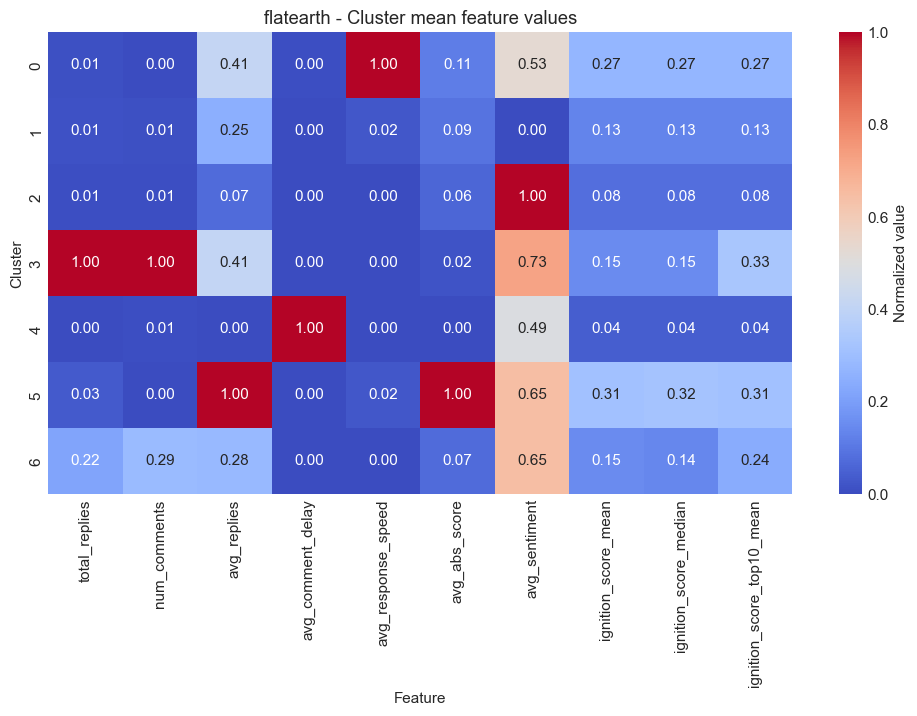

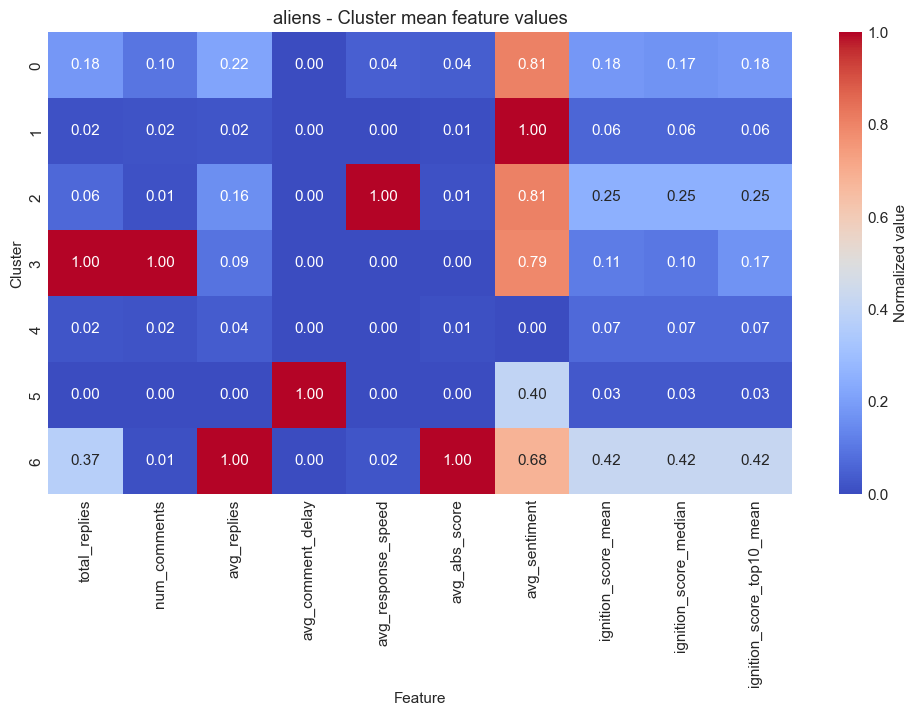

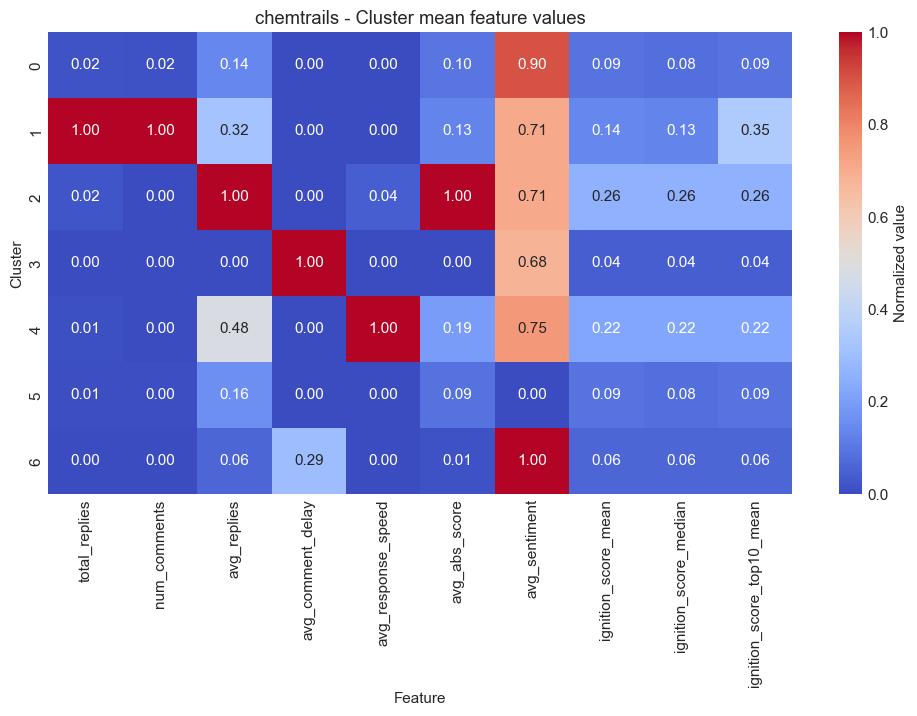

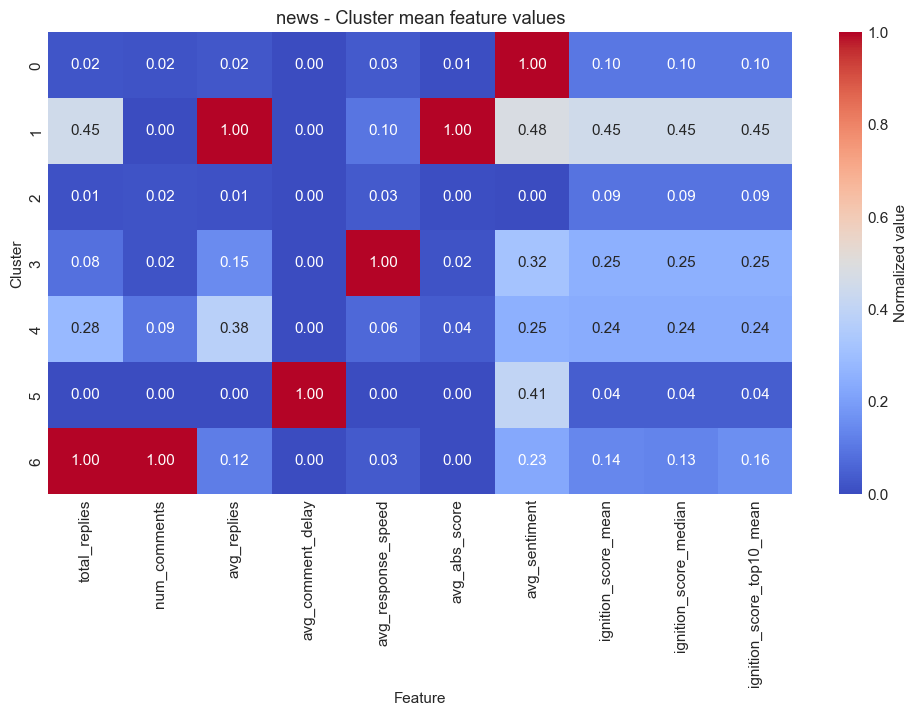

In [17]:
for name, stats in cluster_stats_dict.items():
    mean_stats = stats.xs('mean', level=1, axis=1)

    ignition_cols = ['ignition_score_mean', 'ignition_score_median', 'ignition_score_top10_mean']
    other_cols = [col for col in mean_stats.columns if col not in ignition_cols]

    mean_stats_norm = mean_stats.copy()
    mean_stats_norm[other_cols] = (mean_stats[other_cols] - mean_stats[other_cols].min()) / (
        mean_stats[other_cols].max() - mean_stats[other_cols].min()
    )

    plt.figure(figsize=(12, 6))
    sns.heatmap(
        mean_stats_norm,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        cbar_kws={'label': 'Normalized value'}
    )
    plt.title(f"{name} - Cluster mean feature values")
    plt.ylabel("Cluster")
    plt.xlabel("Feature")
    plt.show()

In [18]:
cluster_centroids = {}

for name, stats in cluster_stats_dict.items():
    cols_to_include = [col for col in stats.columns.levels[0] if col not in ignition_cols]
    cluster_centroids[name] = stats[cols_to_include].xs('mean', level=1, axis=1)

In [19]:
for name, stats in cluster_centroids.items():
    cluster_centroids[name] = (stats - stats.min()) / (stats.max() - stats.min())

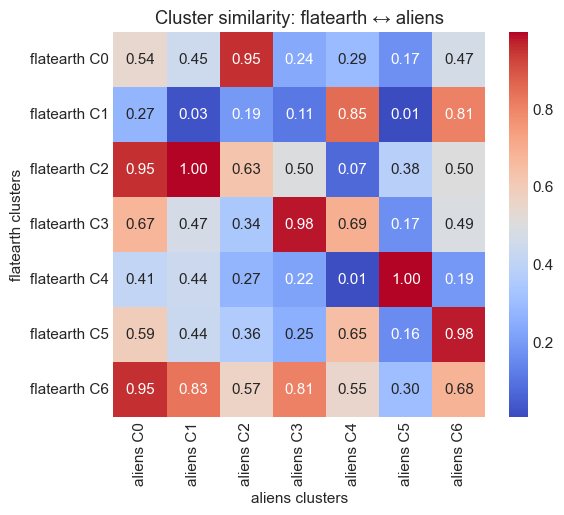

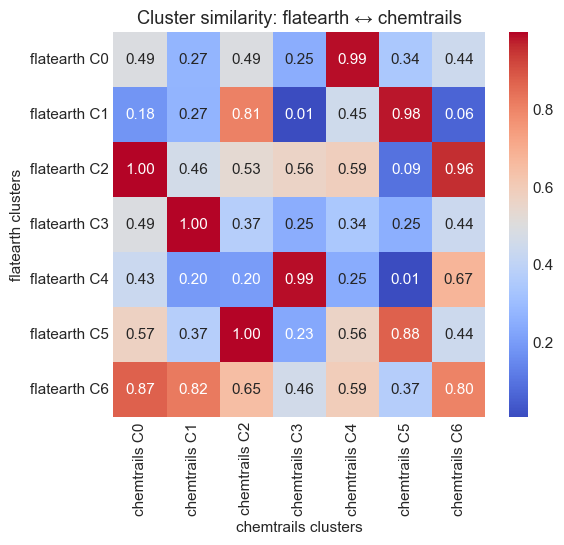

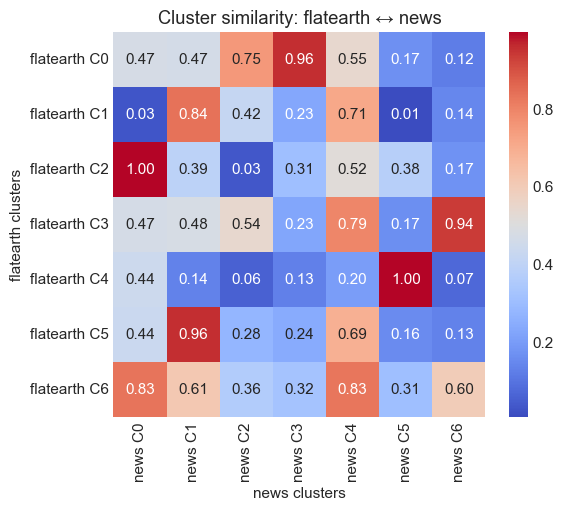

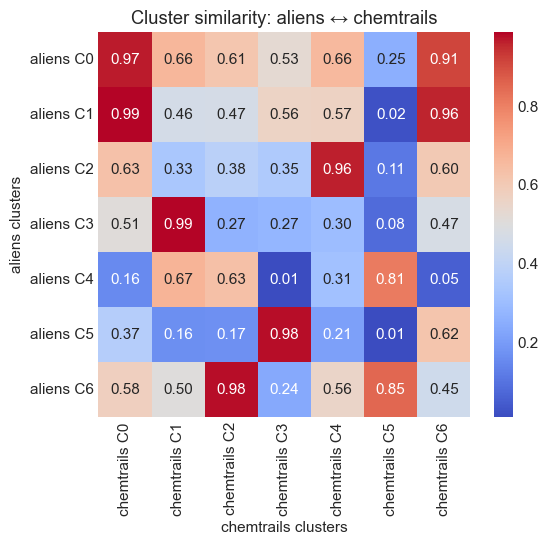

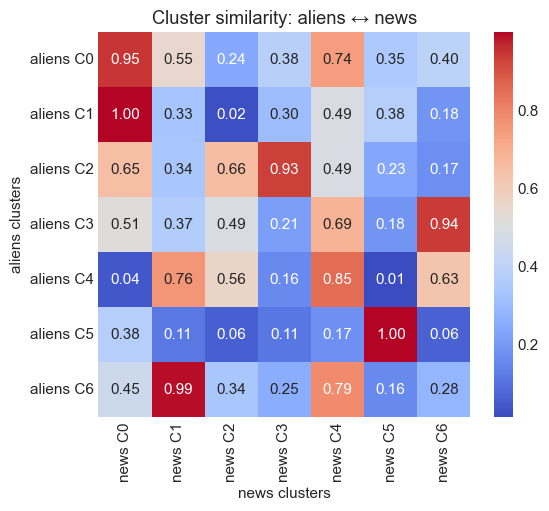

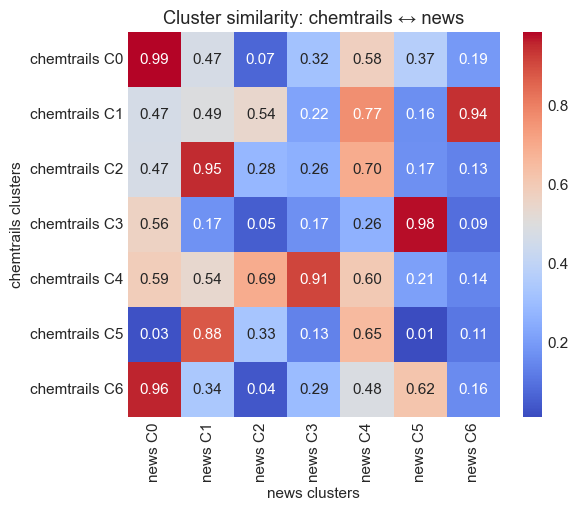

In [20]:
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity

subreddit_names = list(cluster_centroids.keys())
pairs = list(combinations(subreddit_names, 2))

for sub1, sub2 in pairs:
    centroids1 = cluster_centroids[sub1]
    centroids2 = cluster_centroids[sub2]

    sim_matrix = cosine_similarity(centroids1, centroids2)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        sim_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        xticklabels=[f"{sub2} C{i}" for i in range(centroids2.shape[0])],
        yticklabels=[f"{sub1} C{i}" for i in range(centroids1.shape[0])]
    )
    plt.title(f"Cluster similarity: {sub1} ↔ {sub2}")
    plt.xlabel(f"{sub2} clusters")
    plt.ylabel(f"{sub1} clusters")
    plt.show()


In [21]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

ignition_cols = ['ignition_score_mean', 'ignition_score_median', 'ignition_score_top10_mean']

top_ignition_clusters = {}

for name, stats in cluster_stats_dict.items():
    mean_stats = stats.xs('mean', level=1, axis=1)
    top_cluster = mean_stats['ignition_score_mean'].idxmax()
    top_ignition_clusters[name] = top_cluster

top_ignition_clusters

{'flatearth': np.int32(5),
 'aliens': np.int32(6),
 'chemtrails': np.int32(2),
 'news': np.int32(1)}

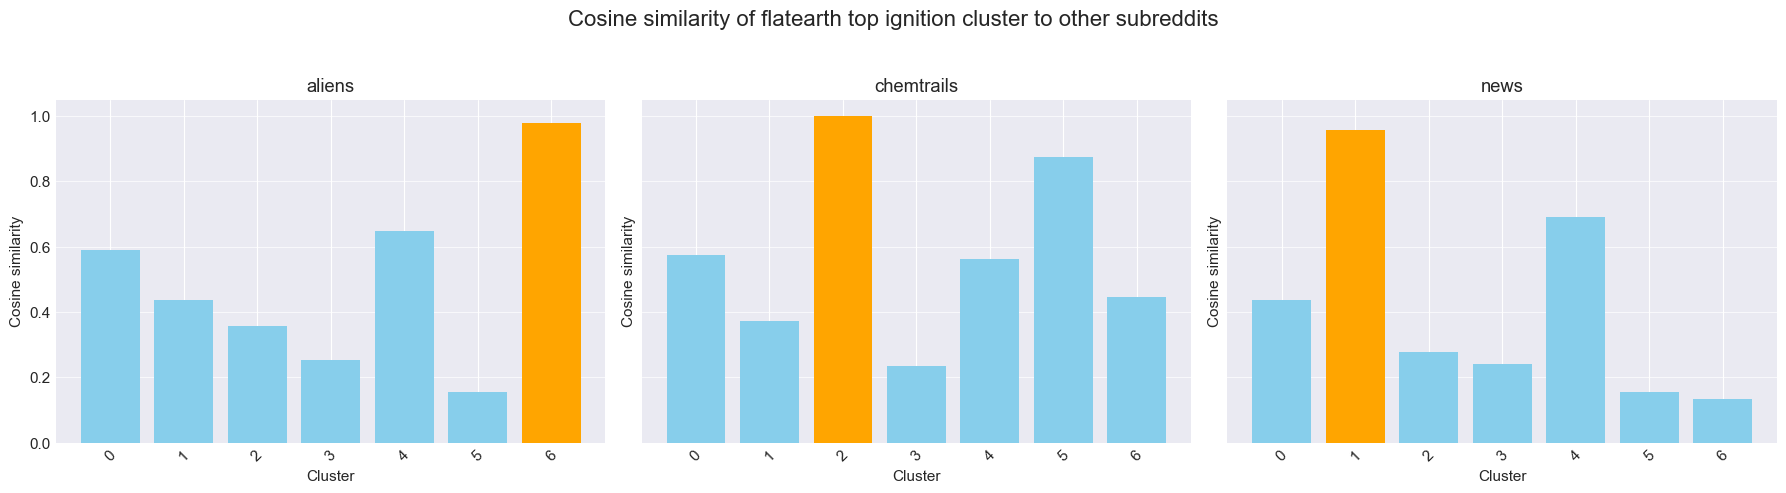

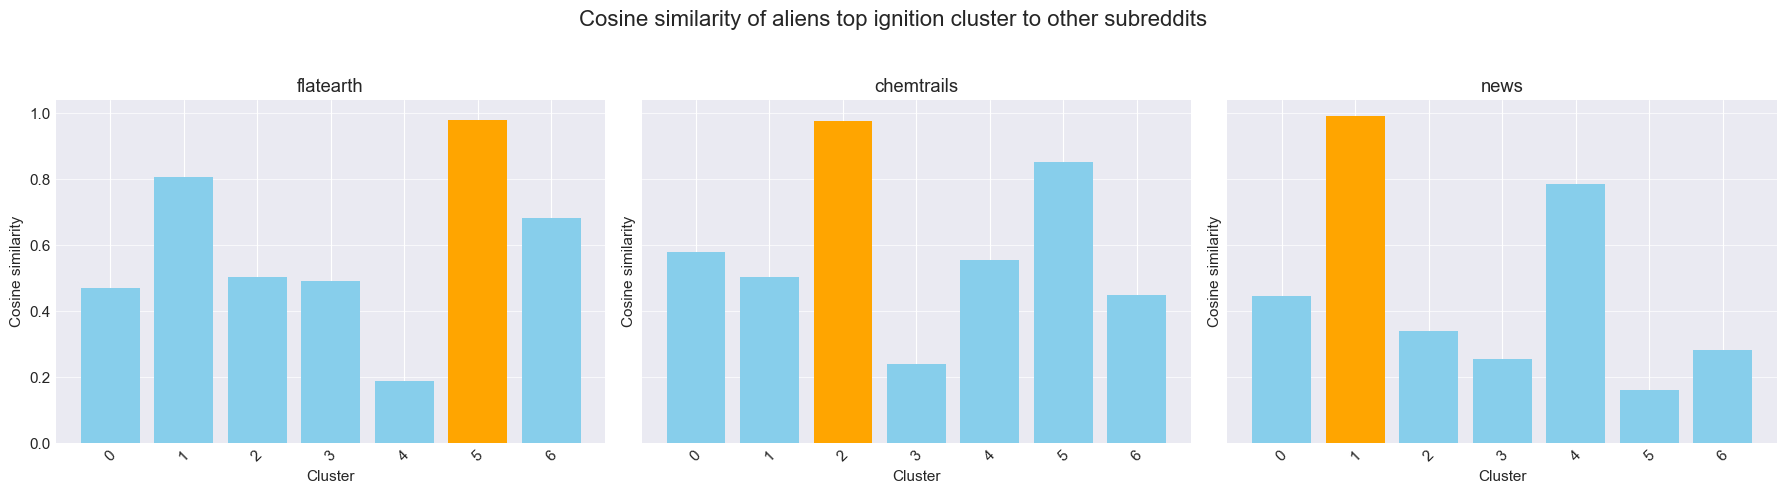

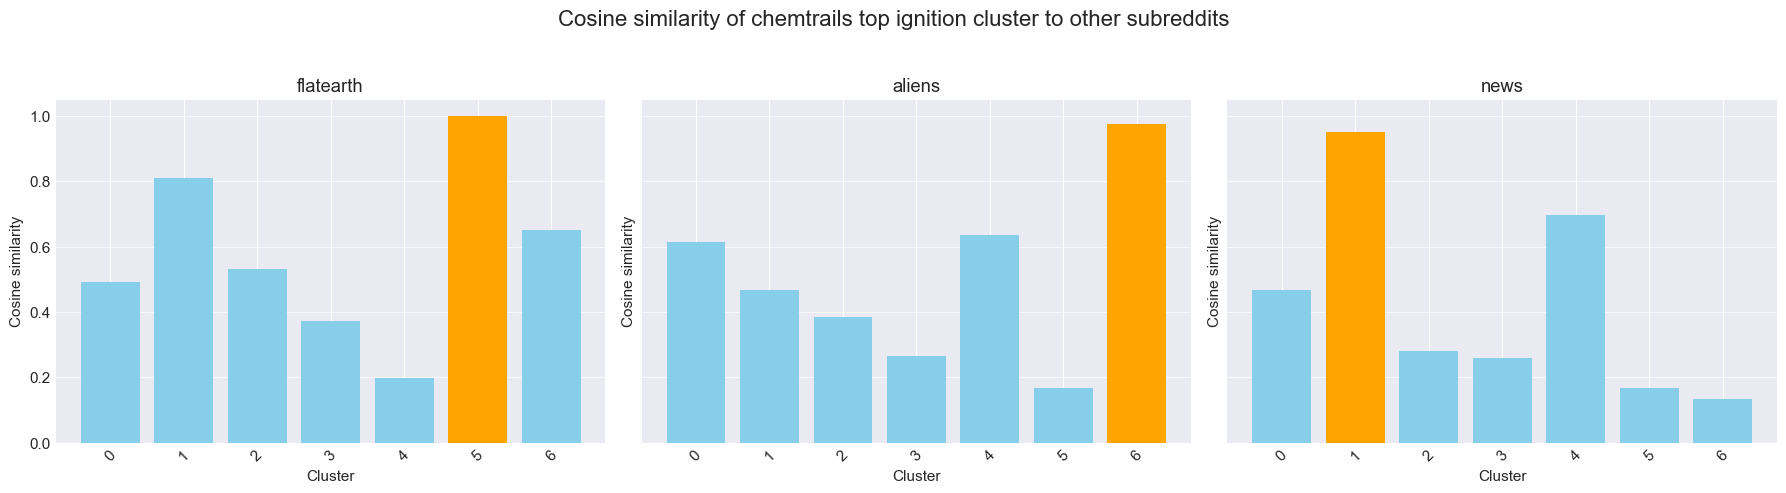

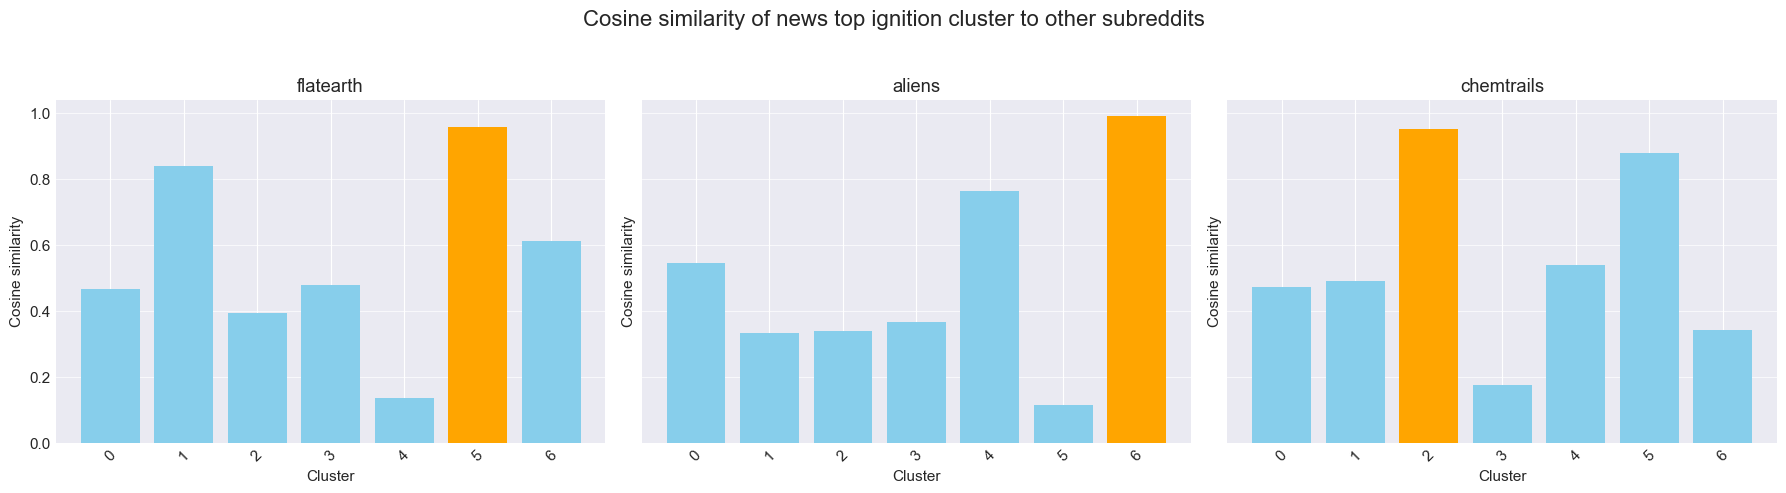

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

subreddits = list(cluster_centroids.keys())
ignition_cols = ['ignition_score_mean', 'ignition_score_median', 'ignition_score_top10_mean']

for subreddit in subreddits:
    top_cluster = top_ignition_clusters[subreddit]
    top_vector = cluster_centroids[subreddit].loc[top_cluster].values.reshape(1, -1)

    other_subs = [s for s in subreddits if s != subreddit]

    fig, axes = plt.subplots(1, len(other_subs), figsize=(18, 5), sharey=True)
    fig.suptitle(f"Cosine similarity of {subreddit} top ignition cluster to other subreddits", fontsize=16)

    if len(other_subs) == 1:
        axes = [axes]

    for ax, other_sub in zip(axes, other_subs):
        df_vectors = cluster_centroids[other_sub]

        sims = cosine_similarity(top_vector, df_vectors.values).flatten()
        sim_df = pd.DataFrame({
            'cluster': df_vectors.index,
            'cosine_similarity': sims
        })

        max_ignition_cluster = top_ignition_clusters[other_sub]
        colors = ['orange' if c == max_ignition_cluster else 'skyblue' for c in sim_df['cluster']]

        ax.bar(sim_df['cluster'], sim_df['cosine_similarity'], color=colors)
        ax.set_title(other_sub)
        ax.set_xlabel("Cluster")
        ax.set_ylabel("Cosine similarity")
        ax.set_xticks(sim_df['cluster'])
        ax.set_xticklabels(sim_df['cluster'], rotation=45)
        ax.grid(axis='y', alpha=0.7)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [23]:
cluster_id_to_name = {v: k for k, v in top_ignition_clusters.items()}
top_cluster_users = {}
ratio_of_users_in_top_cluster = {}

for subreddit, user_df in users_dict.items():
    top_cluster = top_ignition_clusters[subreddit]
    top_users_df = user_df[user_df['cluster'] == top_cluster]
    top_cluster_users[subreddit] = top_users_df
    ratio_of_users_in_top_cluster[subreddit] = len(top_users_df) / len(user_df)

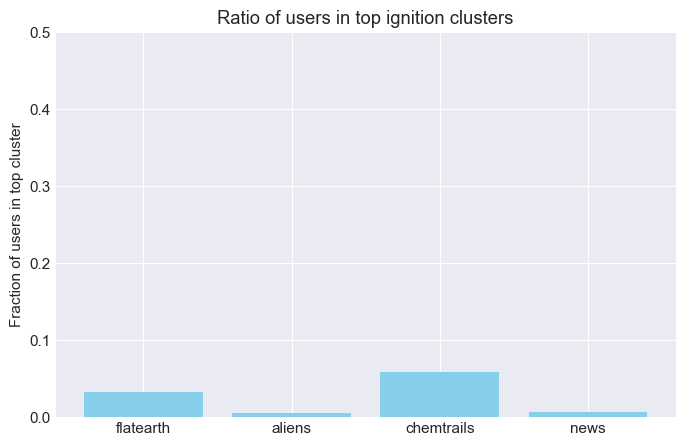

In [24]:
cluster_names = list(ratio_of_users_in_top_cluster.keys())
ratios = list(ratio_of_users_in_top_cluster.values())

plt.figure(figsize=(8, 5))
plt.bar(cluster_names, ratios, color='skyblue')
plt.ylabel('Fraction of users in top cluster')
plt.title('Ratio of users in top ignition clusters')
plt.ylim(0, 0.5)
plt.show()

In [32]:
len(top_cluster_users['flatearth'].index.tolist())

148

In [36]:
cleaned_comments['flatearth'].head()

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,...,post_id,parent_timestamp,num_replies,reply_delay_sec,median_reply_seconds,response_speed,replies_log,score_log,comment_ignition_score,sentiment
1,t1_nox2s20,comment,2025-11-15 02:53:08+00:00,flatearth,zhaDeth,t3_1oxggea,post,gravity,https://www.reddit.com/r/flatearth/comments/1o...,90.000,...,t3_1oxggea,2025-11-15 02:49:46+00:00,2.0,202.0,19636.5,0.000866,0.311543,0.968277,0.398057,0.0000
2,t1_nox5pny,comment,2025-11-15 03:12:27+00:00,flatearth,Just_Ear_2953,t3_1oxggea,post,We HAVE repeatedly observed and measured the c...,https://www.reddit.com/r/flatearth/comments/1o...,104.493,...,t3_1oxggea,2025-11-15 02:49:46+00:00,4.0,1361.0,2984.0,0.005695,0.456402,1.000000,0.479625,-0.9042
3,t1_nox2y8k,comment,2025-11-15 02:54:13+00:00,flatearth,dogsop,t3_1oxggea,post,The stupid part is that it is completely obser...,https://www.reddit.com/r/flatearth/comments/1o...,45.000,...,t3_1oxggea,2025-11-15 02:49:46+00:00,1.0,267.0,366.0,0.046322,0.196562,0.821836,0.315320,-0.5267
4,t1_nox4zax,comment,2025-11-15 03:07:31+00:00,flatearth,Polenicus,t3_1oxggea,post,"Ah yes, declaring Science has been scientifica...",https://www.reddit.com/r/flatearth/comments/1o...,36.000,...,t3_1oxggea,2025-11-15 02:49:46+00:00,0.0,1065.0,NaN,0.000000,0.000000,0.775101,0.193775,0.4019
5,t1_nox650j,comment,2025-11-15 03:15:20+00:00,flatearth,CoolNotice881,t3_1oxggea,post,The upper part is true if it's a few meters la...,https://www.reddit.com/r/flatearth/comments/1o...,31.000,...,t3_1oxggea,2025-11-15 02:49:46+00:00,0.0,1534.0,NaN,0.000000,0.000000,0.743937,0.185984,0.8176


In [39]:
top_cluster_users['flatearth'][top_cluster_users['flatearth']['num_comments'] > 1]

,num_comments,total_replies,avg_replies,avg_comment_delay,avg_response_speed,avg_abs_score,avg_sentiment,ignition_score_mean,ignition_score_median,ignition_score_top10_mean,cluster
brelen01,2,2.0,1.0,380.0,0.003018,37.0000,-0.22020,0.258630,0.258630,0.258630,5
lucypaw68,2,5.0,2.5,10044.5,0.000190,13.0000,0.67250,0.249544,0.249544,0.249544,5
flying_fox86,2,1.0,0.5,150.0,0.044974,25.0000,-0.15755,0.234583,0.234583,0.234583,5
PlayfulAd1711,2,28.0,14.0,620.0,0.009547,32.9155,-0.11690,0.573362,0.573362,0.573362,5
modulair,2,6.0,3.0,2606.0,0.008981,14.5000,0.09650,0.312856,0.312856,0.312856,5
fancy-kitten,7,10.0,1.0,2804.0,0.000879,17.0000,0.00000,0.233565,0.216442,0.233565,5
Ok_Survey86,4,7.0,1.0,460.5,0.100801,29.0000,0.18060,0.325838,0.317718,0.325838,5
Tehjayaluchador,2,7.0,3.5,12652.0,0.006947,11.0000,-0.25530,0.290369,0.290369,0.290369,5
StevieTank,2,2.0,1.0,801.5,0.002014,32.0000,0.00000,0.208578,0.208578,0.208578,5
Pale-Ad-8691,2,1.0,0.5,6791.0,0.000037,24.5000,0.00000,0.172173,0.172173,0.172173,5


In [43]:
for name, top_users_df in top_cluster_users.items():
    all_comments = cleaned_comments[name]

    user_means = (
        top_users_df[["ignition_score_mean"]]
        .reset_index()
        .rename(columns={"index": "author"})
    )

    merged = all_comments.merge(
        user_means,
        on="author",
        how="inner"
    )

    filtered_comments = merged[
        merged["comment_ignition_score"] >= merged["ignition_score_mean"]
    ]

    print(len(filtered_comments))

    filtered_comments.to_csv(
        f"./top_users_top_comments_{name}.csv",
        index=False
    )

170
78
594
190


In [34]:
for name, top_users_df in top_cluster_users.items():
    all_comments = cleaned_comments[name]
    top_users = set(top_users_df.index.tolist())
    top_users_comments = all_comments[all_comments['author'].isin(top_users)]
    print(len(top_users_comments))
    top_users_comments.to_csv(f"./top_users_comments_{name}.csv")

221
96
868
215


In [35]:
for name, top_users_df in top_cluster_users.items():
    all_comments = cleaned_comments[name]
    top_users = set(top_users_df.index.tolist())
    top_users_comments = all_comments[all_comments['author'].isin(top_users)]
    print(len(top_users_comments))
    top_users_comments.to_csv(f"./top_users_comments_{name}.csv")

221
96
868
215
